# DES-UCB. Drift-triggered Evidence-Switching UCB

Research prototype for the paper *Drift-triggered evidence switching suppresses stale priors in
cold-start interactive recommendation*. One notebook and one tested helper module
(`des_ucb_core.py`). Every number below comes from running this notebook top to bottom. Nothing is
pre-filled.

## 1. Method

**Background components.**

* **SW-UCB.** Sliding-window LinUCB. Its dynamic regret is optimal when the variation budget is
  known (Garivier and Moulines 2011, Cheung, Simchi-Levi and Zhu 2019).
* **Bandit-over-Bandit (BOB).** EXP3 over candidate window lengths, updated once per block of
  length `H`. Meant for an unknown variation budget (Cheung, Simchi-Levi and Zhu 2019).
  Baseline **B4**.
* **Change-point-triggered restarts.** Detect a shift in the residual stream and restart the
  estimator. Page-Hinkley and ADWIN (Bifet and Gavaldà 2007) are the usual tests. Baseline **B6**
  takes this route.
* **Detection-augmented and restarted learners.** A stationary base learner wrapped by a change
  detector with forced exploration (DAL, Gerogiannis et al. 2025, DAB, Huang et al. 2025), or by a
  periodic restart schedule (Zhao et al. 2020, and the restarted weighted variants of Wang et al.
  2024). Baselines **B10** and **B11**.

**DES-UCB.** A cold-start user arrives with two kinds of evidence.

* **P** (prior-driven). A ridge fit on the pre-interaction rows `D_prior`. These rows can come from
  a cohort, from demographics or from the user's own stale history. P stays frozen unless
  `alpha_prior_mix > 0`.
* **F** (feedback-driven). A sliding-window ridge on this user's live rows only.
* **C** (pooled). A ridge fit on the prior rows plus every live row since the last purge. Under a
  stationary preference C equals warm-started LinUCB (B2). After a drift it still carries the stale
  prior rows. So C misleads exactly when the prior does.

DES-UCB adds two pieces on top.

1. A **meta-controller** (`EvidenceSwitch`, Hedge over `{C, F}` by default). Each round it picks the
   source the UCB is conditioned on. Every source can be scored on the observed `(x_t, r_t)` pair.
   So the controller sees the full loss vector (clipped squared error of every source), not just the
   loss of the source it played. An **agreement gate** skips the controller when all sources pick the
   same arm. The common arm is played, F is conditioned on, and no exploration is paid.
2. A **drift-triggered suppression step.** A Page-Hinkley test watches the squared residual of the
   active source. When it fires, the live feedback is purged down to `purge_keep` rows (default 0,
   a full feedback restart). C is rebuilt from the prior rows and the kept rows. The credit of the
   prior-carrying source is reset. F alone is used for a burn-in of at least `B` rounds. This
   replaces passive decay of the prior.

The window length itself is chosen by BOB. Ablations A1 to A10 remove one piece at a time.

### Theory note

What is proved (checked numerically in `tests/test_core.py`). Take `gamma = 0` and losses in
`[0, 1]`. Over any `n` credited rounds, the expected clipped squared-error loss of the source the
controller conditions on exceeds that of the best fixed source by at most `ln K / eta + eta n / 8`.
This is the standard Hedge bound. It is a prediction-loss guarantee for the controller.

What is not proved. A dynamic-regret bound of the form
`R_T(DES-UCB) <= R_T(SW-UCB/BOB) + O(sqrt(T)) + N_fired * B * Delta_max`. The credit signal is
conditional on the arm the active source chose. A prediction-loss bound therefore does not turn
into a regret bound without more assumptions. This stays a proof obligation. It is tested only
empirically in section 13. On real data none of this applies. `offline_regret` (best rated
candidate) is not dynamic regret.

In [1]:
import copy, json, math, time, warnings, os
from pathlib import Path
import numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 11, "axes.titlesize": 11, "axes.labelsize": 11, "legend.fontsize": 10, "xtick.labelsize": 10, "ytick.labelsize": 10})
import des_ucb_core as C

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", module="urllib3")
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
RES = C.RESULTS_DIR; RES.mkdir(exist_ok=True)
T_START = time.time()

def show(df, floatfmt=".3f"):
    print(df.to_markdown(floatfmt=floatfmt))

def savefig(name):
    plt.tight_layout(); plt.savefig(RES / f"{name}.png", dpi=220); plt.show()
    # plt.savefig(RES / f"{name}.pdf")  # vector copies, not needed since the paper uses the png

# TODO: move show/savefig into des_ucb_core so the scripts can reuse them

CFG = C.load_config()
print(json.dumps({k: v for k, v in CFG.items() if k != "experiments"}, indent=1, default=str)[:1500])

{
 "seed": 0,
 "n_seeds": 5,
 "n_users": 100,
 "T": 2000,
 "d": 16,
 "N_items": 500,
 "K_cand": 20,
 "lam": 1.0,
 "beta": 0.5,
 "S": 5.0,
 "switch": {
  "kind": "hedge",
  "sources": [
   "C",
   "F"
  ],
  "gate": true,
  "eta": 2.0,
  "gamma": 0.0,
  "exp3_gamma": 0.05,
  "c": 1.0,
  "G": 1.0
 },
 "alpha_prior_mix": 0.0,
 "purge_keep": 0,
 "w_0": 100000,
 "w_min": 50,
 "candidate_windows": [
  100,
  400,
  1600,
  100000
 ],
 "H": 100,
 "bob_gamma": 0.1,
 "burn_in_B": 30,
 "reward_range": [
  -2.0,
  2.0
 ],
 "detector": {
  "type": "page_hinkley",
  "delta": 0.005,
  "lam_threshold": 1.0,
  "alpha_forget": 0.999,
  "min_instances": 30
 },
 "prior": {
  "K_cohorts": 8,
  "n_prior_rows": 200,
  "sigma_prior": 0.1,
  "p_mismatch": 0.0,
  "prior_from_pre_drift": true
 },
 "drift": {
  "type": "abrupt",
  "change_points": [
   600,
   1300
  ],
  "magnitude": 1.0,
  "direction": "random",
  "sigma_reward": 0.1,
  "reward_model": "gaussian",
  "gradual_G": 300,
  "recurring_P": 500,
  "i

## 2. Synthetic environment

Dynamic regret is defined here and nowhere else.

`SyntheticEnv` has `N_items` unit-norm contexts, `K_cohorts` prototypes and a hidden user
parameter `theta_t`. The reward is `r = x^T theta_t + N(0, sigma^2)`, or Bernoulli(sigmoid) if
configured. The oracle is `max_a x_a^T theta_t` over the `K_cand` candidates. Drift types are
none, abrupt, gradual, recurring, incremental and sinusoidal. `drift.magnitude` is
`||theta_1 - theta_0||`.

Three **staleness knobs** are ablated one at a time in section 9.

* `p_mismatch`. The prior is drawn from the wrong cohort (misspecified prior).
* `prior_from_pre_drift`. The prior is built from `theta_0` and the user drifts to `theta_1`. This
  is the stale-prior case in the title. Default `true`.
* `sigma_prior`. A weak but unbiased prior. Suppression should not help here.

Sanity plot. `||theta_t - theta_0||` per drift type for one user.

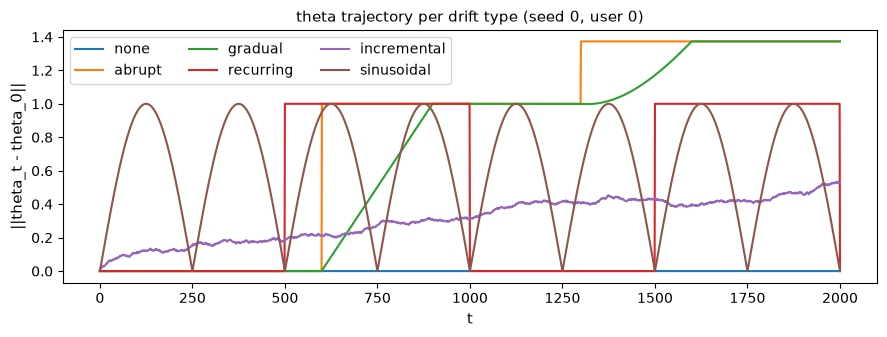

d = 16 | T = 2000 | D_prior rows = 200 | regret_kind = dynamic


In [2]:
DRIFTS = ["none", "abrupt", "gradual", "recurring", "incremental", "sinusoidal"]
fig, ax = plt.subplots(1, 1, figsize=(9, 3.5))
for dt in DRIFTS:
    cfg_dt = C.load_config(f"drift_{dt}")
    env = C.SyntheticEnv(cfg_dt, seed=0, user=0)
    dev = np.linalg.norm(env.thetas - env.theta0, axis=1)
    ax.plot(dev, label=dt)
ax.set_xlabel("t"); ax.set_ylabel("||theta_t - theta_0||"); ax.legend(ncol=3); ax.set_title("theta trajectory per drift type (seed 0, user 0)")
savefig("theta_trajectories")
env = C.SyntheticEnv(CFG, 0, 0)
print("d =", env.d, "| T =", env.T, "| D_prior rows =", len(env.D_prior[1]), "| regret_kind =", env.regret_kind)

## 3. Real-data loaders

All loaders share the `Env` interface. Each dataset is optional and switched on in `cfg.datasets`.

**Rule for real data.** The environment can only reveal rewards of items the user actually rated
or saw. So (a) the candidates are `K_cand` rated and not yet shown items, or the actual impression
list for MIND. (b) The "oracle" is the best available reward in that candidate set. (c) The
resulting quantity is `offline_regret`, never dynamic regret. (d) The primary metrics are
cumulative precision@T and recall@T. A hit is a rating of 4 or more, or a click. This follows the
ICF and NICF protocol.

* **ML-1M** (required, ML-100K as a smoke switch). 18 genre one-hots plus an SVD item embedding
  fit on train-user ratings. User-disjoint 85/5/10 split. Users with at least 100 ratings.
  Protocol **A** is cold start. Protocol **B** is induced drift (chronological half-split, the prior
  is the user's own early half). Protocol **C** is a stale prior from a different demographic cohort
  with probability `p_mismatch`.
* **MIND-small** (required if the network permits). TF-IDF on titles, then SVD, plus category
  one-hots. Reward is a click. Candidates are the actual impression list. Chronological order.
  Detector firings are compared with calendar-day boundaries. The official Azure blob refuses
  anonymous downloads (HTTP 409), so the raw TSVs come from a public Hugging Face mirror.
* **KuaiRand-Pure** (fetched from Zenodo, CC BY-SA 4.0). The random-exposure log from 04/22 to
  05/08 gives (user, day) groups whose exposures were drawn uniformly at random. The first `K`
  exposures of a group form the candidate set. A uniform row of it is the logged action and its
  `is_click` is the reward. The **replay estimator** (`replay_reward`) is therefore unbiased for
  on-policy reward. Video features are an SVD of category and tag one-hots plus log exposure
  statistics. `D_prior` is drawn from the earlier standard-policy log (04/08 to 04/21). It is a
  population prior that precedes the evaluation window.
* **Yahoo R6.** Optional and licence-gated (Webscope). Not available in this run unless
  `datasets.yahoo_r6_path` points at a local copy. No R6 number appears anywhere below.
* **Netflix and Amazon-2023.** Optional, gated on local paths and flags. Amazon only ever serves as
  a cross-category `D_prior` (review time is not purchase time).

Loaders cache parquet under `data/` and print a stats table. This section only loads and
describes the data. The experiments are in section 10.

In [3]:
DS = CFG["datasets"]; REAL = {}
def try_load(name, fn):
    try:
        t0 = time.time(); REAL[name] = fn(); print(f"[{name}] ready in {time.time()-t0:.1f}s")
    except Exception as e:  # a failed download or a missing path should not stop the run
        print(f"[{name}] SKIPPED: {type(e).__name__}: {str(e)[:200]}")

if DS.get("movielens_100k_smoke"):
    CFG_ML100K = C.load_config("movielens_100k")
    try_load("ml-100k", lambda: C.prepare_movielens(CFG_ML100K, "ml-100k"))
if DS.get("movielens_1m"):
    CFG_ML1M = C.load_config("movielens_1m")
    try_load("ml-1m", lambda: C.prepare_movielens(CFG_ML1M, "ml-1m"))
if DS.get("mind_small"):
    CFG_MIND = C.load_config("mind_small")
    try_load("mind", lambda: C.prepare_mind(CFG_MIND))
if DS.get("netflix") and DS.get("netflix_path"):
    CFG_NF = C.load_config("netflix")
    try_load("netflix", lambda: C.load_netflix(DS["netflix_path"], CFG_NF))
if DS.get("yahoo_r6_path"):
    try_load("yahoo_r6", lambda: C.load_yahoo_r6(DS["yahoo_r6_path"]))
if DS.get("kuairand"):
    try_load("kuairand", lambda: C.load_kuairand_random(DS.get("kuairand_path"), d=CFG["d"], K=int(DS.get("kuairand_K", 10)),
                                                          n_prior_rows=int(CFG["prior"]["n_prior_rows"])))
    if "kuairand" in REAL:
        e = REAL["kuairand"]
        print(f"kuairand: {e.T} replay rounds (user-day groups of the random log), mean logged click {e.r.mean():.3f}, "
              f"D_prior = {len(e.D_prior[1])} rows of the 04/08-04/21 standard log (mean click {e.D_prior[1].mean():.3f})")
else:
    print("kuairand: disabled in cfg.datasets")
if not DS.get("yahoo_r6_path"):
    print("yahoo_r6: NOT AVAILABLE - Yahoo! Webscope R6 requires a signed licence; set datasets.yahoo_r6_path to the local file to enable")
if DS.get("amazon_2023"):
    print("WARNING: Amazon Reviews 2023 review time != purchase time; used ONLY to build a cross-category D_prior, never for drift claims.")
    try_load("amazon_prior", lambda: C.amazon_cross_category_prior(C.load_config("amazon_2023"), d=CFG["d"]))
for k, v in REAL.items():
    if isinstance(v, C.RatedDataset):
        print(f"{k}: d={v.d}, test users={len(v.test_users)}, cohorts={len(v.cohort_rows)}")

| dataset   |   #users |   #items |   #interactions | span                     |
|:----------|---------:|---------:|----------------:|:-------------------------|
| ml-100k   |      943 |     1682 |          100000 | 1997-09-20 .. 1998-04-22 |
[ml-100k] ready in 0.7s
| dataset   |   #users |   #items |   #interactions | span                     |
|:----------|---------:|---------:|----------------:|:-------------------------|
| ml-1m     |     6040 |     3706 |         1000209 | 2000-04-25 .. 2003-02-28 |


[ml-1m] ready in 0.7s


| dataset                  |   #users |   #items |   #interactions | span                     |
|:-------------------------|---------:|---------:|----------------:|:-------------------------|
| MIND-small (impressions) |    50000 |     5910 |          156965 | 2019-11-09 .. 2019-11-14 |


[mind] ready in 13.6s


[kuairand] ready in 2.1s
kuairand: 155887 replay rounds (user-day groups of the random log), mean logged click 0.183, D_prior = 200 rows of the 04/08-04/21 standard log (mean click 0.505)
yahoo_r6: NOT AVAILABLE - Yahoo! Webscope R6 requires a signed licence; set datasets.yahoo_r6_path to the local file to enable
ml-100k: d=34, test users=37, cohorts=75
ml-1m: d=34, test users=295, cohorts=14
mind: d=49, test users=94, cohorts=6


## 4. Runner

`C.run(env_factory, agents, cfg, n_seeds, n_users, exp_name)` loops over seeds, users, agents and
rounds. The (seed, user) jobs run in a multiprocessing pool. Each round is logged with
`seed, user, t, agent, reward, oracle_or_best_available, regret_kind, regret, source, window,
drift_fired, true_change, forced`. `regret_kind` is one of `dynamic`, `offline` or `replay`.
DES-type agents also log the switch diagnostics `e_P, e_F, gain, agreed, pol_gap_F_minus_P`. The
last one is the full-information policy gap `E[r(a_F)] - E[r(a_P)]` and exists only in simulation.
The log is saved to `results/<exp>.parquet`.

Every agent of a job sees the identical environment. `env.reset()` is called between agents and
the noise is pre-drawn. Comparisons are therefore paired. `seeds=` takes an explicit seed list. It
keeps the tuning seeds of section 6b disjoint from the evaluation seeds.

In [4]:
def synth_factory(cfg):
    return lambda seed, user: C.SyntheticEnv(cfg, seed, user)

# tuned hyper-parameters (section 6b) as dotted keys, applied to every later run
# empty until section 6b has run
TUNED = {}
def tuned(cfg):
    for k, v in TUNED.items():
        cfg = C.set_dotted(cfg, k, v)
    return cfg

def run_synth(cfg, agents, size, exp_name, seeds=None, **over):
    ex = dict(cfg["experiments"][size]); ex.update(over)
    T = ex.get("T", cfg["T"])
    o = {"T": T}
    if "change_points" in ex:
        o["drift"] = {"change_points": ex["change_points"]}
    cfg2 = tuned(C._deep_update(cfg, o))
    return C.run(synth_factory(cfg2), agents, cfg2, n_seeds=ex["n_seeds"], n_users=ex["n_users"], exp_name=exp_name,
                 seeds=seeds), cfg2

smoke, _ = run_synth(CFG, ["DES-UCB", "B2"], "pilot", None, n_seeds=1, n_users=2, T=200)
print(smoke.head(3).to_string()); print(smoke.dtypes.to_dict())

run:   0%|          | 0/2 [00:00<?, ?it/s]

   seed  user  t    agent    reward  oracle_or_best_available regret_kind    regret source  window  drift_fired  true_change  forced       e_P       e_F       e_C      gain  agreed  pol_gap_F_minus_P
0     0     1  0  DES-UCB  0.543212                  0.586961     dynamic  0.000000      C  100000        False        False    True  0.000701  0.295079  0.000701  0.995261     0.0          -0.332319
1     0     1  1  DES-UCB  0.359428                  0.354790     dynamic  0.021558      C  100000        False        False    True  0.003113  0.044920  0.003250  0.865080     0.0           0.000000
2     0     1  2  DES-UCB  0.231309                  0.273939     dynamic  0.028374      C  100000        False        False    True  0.002042  0.014512  0.002079  0.749344     0.0          -0.303075
{'seed': dtype('int32'), 'user': dtype('int32'), 't': dtype('int32'), 'agent': CategoricalDtype(categories=['B2', 'DES-UCB'], ordered=False, categories_dtype=str), 'reward': dtype('float64'), 'oracle_

## 5. Metrics

Two namespaces. They are never mixed.

**Synthetic (dynamic).** `dynamic_regret = sum_t (oracle_t - r_t)` and its per-round curve.
Recovery time, the rounds until the 20-round moving-average regret is back within 10% of the
pre-drift level. `stale_evidence_ratio`, the share of post-change rounds conditioned on a
prior-carrying source (`P` or `C`). Detection delay and false alarms. Cold-start mean reward at
t = 10, 20 and 50. Log-log regret slope against T.

**Real (offline and replay).** `cum_precision@{5,10,20,40}`, `cum_recall@T` and `offline_regret`
(rated-candidate oracle). `replay_reward` where a random-logging slice exists.
`stale_evidence_ratio` around the induced split.

All metrics are reported as mean and std over (seed, user) units, with **paired 95% CIs** for
method differences (`C.summarize_pairs`). Units of one seed share the item set and the cohort
prototypes, so they are not independent. Three intervals are therefore given. The flat unit
bootstrap (`ci_*`) is kept for reference. The **two-stage seed-clustered bootstrap** (`cl_*`)
resamples seeds and then users within each drawn seed. A t-interval over per-seed means
(`seed_*`) completes the set. The confirmatory rule (`ci_excludes_0`) uses the clustered
bootstrap. Every metric function asserts the namespace of its input (`C._assert_kind`). Mixing
raises an error.

In [5]:
show(C.dynamic_regret(smoke))
try:
    C.offline_regret(smoke)
except ValueError as e:
    print("namespace guard OK ->", e)

| agent   |   dynamic_regret_mean |   dynamic_regret_std |   n_units |
|:--------|----------------------:|---------------------:|----------:|
| B2      |                 0.306 |                0.029 |     2.000 |
| DES-UCB |                 0.306 |                0.029 |     2.000 |
namespace guard OK -> metric namespace mismatch: expected only 'offline', log contains ['dynamic']


## 6. Pilot

The pilot runs first and takes under 5 minutes. One seed, 20 users, T = 1000, abrupt drift at
t = 500, `prior_from_pre_drift = true`, `p_mismatch = 0`. Agents are DES-UCB, A2 (no suppression)
and B4 (BOB). It prints detection delay, dynamic regret, the stale-evidence ratio and the
decision-table branch (section 13) that applies so far. Everything below runs regardless. The
pilot verdict is recorded.

**Recorded pilot observation.** With the original `lam_threshold = 50` the Page-Hinkley test never
fired on squared residuals of rewards with `sigma_reward = 0.1`. The first pilot detected 0 of 20
changes. That is the "DETECTION FAILURE" branch of the decision table. `configs/default.yaml`
therefore ships `lam_threshold = 1.0`. In the retest this gave 20 of 20 detections, a mean delay
below `burn_in_B` and 0 false alarms on `drift=none`. The cell below re-checks this on the current
run. The value is only a starting point. The threshold used in every later section is selected by
the tuning protocol of section 6b, on seeds disjoint from the evaluation seeds and with the same
rule for every method.

**Counting convention.** `n_changes` counts true change events (units times change points per
unit). `detected` counts events followed by a firing within `fa_window` rounds. Both integers are
printed. The percentage is their ratio.

In [6]:
PILOT_AGENTS = ["DES-UCB", "A2", "B4"]
pilot_cfg = C.load_config("drift_abrupt", overrides={"prior": {"prior_from_pre_drift": True, "p_mismatch": 0.0}})
pilot, pilot_cfg2 = run_synth(pilot_cfg, PILOT_AGENTS, "pilot", "pilot")
pilot_reg = C.dynamic_regret(pilot); pilot_det = C.detection_stats(pilot); pilot_stale = C.stale_evidence_ratio(pilot)
print("dynamic regret (mean over units)"); show(pilot_reg)
print("\ndetection"); show(pilot_det)
print("\nstale evidence ratio (post-change rounds on a prior-carrying source P or C)"); show(pilot_stale.to_frame())
pilot_reg.to_csv(RES / "pilot_regret.csv"); pilot_det.to_csv(RES / "pilot_detection.csv")

pilot_delay = float(pilot_det.loc["DES-UCB", "mean_delay"])
pilot_pairs = C.summarize_pairs(C.per_unit(pilot), [("DES-UCB", "A2"), ("DES-UCB", "B4")])
show(pilot_pairs)
PILOT_VERDICT = {
    "detector_mean_delay": pilot_delay, "burn_in_B": pilot_cfg2["burn_in_B"],
    "detected_events": int(pilot_det.loc["DES-UCB", "detected"]), "n_change_events": int(pilot_det.loc["DES-UCB", "n_changes"]),
    "detected_fraction": float(pilot_det.loc["DES-UCB", "detected"] / max(1, pilot_det.loc["DES-UCB", "n_changes"])),
    "branch": ("DETECTION FAILURE: tune PH threshold, retest" if (math.isnan(pilot_delay) or pilot_delay > pilot_cfg2["burn_in_B"])
               else "detector OK (delay <= B); suppression verdict deferred to section 13 (needs 5 seeds x 100 users)"),
    "DES_minus_A2_regret": float(pilot_pairs.iloc[0]["mean_diff(A-B)"]), "DES_minus_B4_regret": float(pilot_pairs.iloc[1]["mean_diff(A-B)"]),
}
print("\nPILOT VERDICT:", json.dumps(PILOT_VERDICT, indent=1))
(RES / "pilot_verdict.json").write_text(json.dumps(PILOT_VERDICT, indent=1))

pilot:   0%|          | 0/20 [00:00<?, ?it/s]

dynamic regret (mean over units)
| agent   |   dynamic_regret_mean |   dynamic_regret_std |   n_units |
|:--------|----------------------:|---------------------:|----------:|
| A2      |                37.854 |               12.194 |    20.000 |
| B4      |                36.986 |               14.149 |    20.000 |
| DES-UCB |                13.882 |                4.098 |    20.000 |

detection
| agent   |   n_changes |   detected |   missed |   mean_delay |   median_delay |   false_alarms_per_unit |   total_firings |
|:--------|------------:|-----------:|---------:|-------------:|---------------:|------------------------:|----------------:|
| A2      |      20.000 |     20.000 |    0.000 |       25.150 |         21.500 |                   0.050 |          22.000 |
| B4      |      20.000 |      0.000 |   20.000 |      nan     |        nan     |                   0.000 |           0.000 |
| DES-UCB |      20.000 |     20.000 |    0.000 |       24.750 |         21.500 |                

324

## 6b. Tuning protocol

The same rule for every method, on separate seeds. Every method with a free hyper-parameter is
tuned by the same routine (`C.tune_method`).

* Tuning data. `tuning.seeds` (100, 101), disjoint from the evaluation seeds 0 to 9. 20 users,
  T = 2000, two regimes. No drift, and abrupt drift with a stale pre-drift prior.
* Criterion. The mean over the two regimes of `regret / best regret of the grid in that regime`.
  A method cannot buy drift performance with a setting that is bad when nothing changes. Ties go
  to the first grid entry. No checkpoint selection.
* Grids (`tuning.grids` in `default.yaml`). DES-UCB `lam_threshold x switch.eta` (12 points). B3
  window (5). B4 BOB exploration rate (3). B5 discount (4). B6 Page-Hinkley threshold (5). B10
  forced-exploration rate x GLR threshold (9). B11 restart period (4). The shared parameters
  `lam, beta, S, w_0, w_min, candidate_windows, H, burn_in_B` are fixed for all.

The selected values go to `results/tuning_selected.json` and the full table to
`results/tuning_table.csv`. They are applied to every later experiment through `tuned()`. Any
setting inherited by an ablation or variant (A1 to A10, V1 to V4) is the tuned DES-UCB setting.

In [7]:
TU = CFG["tuning"]
tune_rows, TUNED_SEL = [], {}
cfg_tune = C.load_config("drift_abrupt", overrides={"T": TU["T"], "prior": {"prior_from_pre_drift": True, "p_mismatch": 0.0}})
for method, grid in TU["grids"].items():
    sel, tab = C.tune_method(synth_factory, method, grid, cfg_tune, seeds=TU["seeds"], n_users=TU["n_users"],
                             regimes=[str(r) for r in TU["regimes"]])
    tune_rows.append(tab); TUNED_SEL[method] = {k: (float(v) if isinstance(v, (float, np.floating)) else int(v)) for k, v in sel.items()}
    print(f"{method}: selected {TUNED_SEL[method]}  (grid of {len(tab)})")
TUNETAB = pd.concat(tune_rows, ignore_index=True); TUNETAB.to_csv(RES / "tuning_table.csv", index=False)
for m, sel in TUNED_SEL.items():
    TUNED.update(sel)
(RES / "tuning_selected.json").write_text(json.dumps({"seeds": TU["seeds"], "n_users": TU["n_users"], "T": TU["T"],
    "criterion": "min over the grid of the mean, over regimes " + "/".join(map(str, TU["regimes"])) + ", of regret relative to the best grid point of that regime (stale pre-drift prior)", "selected": TUNED_SEL,
    "shared_fixed": {k: CFG[k] for k in ["lam", "beta", "S", "w_0", "w_min", "candidate_windows", "H", "burn_in_B"]}}, indent=1))
show(TUNETAB.set_index("method"), ".3f")
print("\napplied to all later runs:", TUNED)

DES-UCB: selected {'detector.lam_threshold': 0.5, 'switch.eta': 8.0}  (grid of 12)


B3: selected {'baselines.sw_window': 200}  (grid of 5)


B4: selected {'baselines.bob_gamma': 0.05}  (grid of 3)


B5: selected {'baselines.discount_gamma': 0.995}  (grid of 4)


B6: selected {'baselines.ph_restart_lam_threshold': 1.0}  (grid of 5)


B10: selected {'baselines.dal_alpha': 0.02, 'baselines.dal_glr_threshold': 2.0}  (grid of 9)


B11: selected {'baselines.restart_period': 1000}  (grid of 4)
| method   |   detector.lam_threshold |   switch.eta |   regret_none |   regret_std_none |   n_units |   regret_abrupt |   regret_std_abrupt |   criterion |   regret_mean |   baselines.sw_window |   baselines.bob_gamma |   baselines.discount_gamma |   baselines.ph_restart_lam_threshold |   baselines.dal_alpha |   baselines.dal_glr_threshold |   baselines.restart_period |
|:---------|-------------------------:|-------------:|--------------:|------------------:|----------:|----------------:|--------------------:|------------:|--------------:|----------------------:|----------------------:|---------------------------:|-------------------------------------:|----------------------:|------------------------------:|---------------------------:|
| DES-UCB  |                    0.500 |        1.000 |         2.012 |             1.508 |    40.000 |          24.950 |               6.073 |       1.107 |        13.481 |               nan

## 7. Synthetic full grid

All drift types against all baselines and DES-UCB. For each drift type (`configs/drift_*.yaml`)
B1 to B11 and DES-UCB are run. Reported are mean and std of dynamic regret, recovery time and
cold-start reward. Sizes come from `experiments.grid` in `default.yaml`. They are scaled to fit
the 30-minute budget. The claim registry re-runs the claim-relevant cells at full size.

In [8]:
GRID_AGENTS = ["DES-UCB"] + C.ALL_BASELINES
grid_logs, grid_rows = {}, []
for dt in DRIFTS:
    cfg_dt = C.load_config(f"drift_{dt}")
    df, _ = run_synth(cfg_dt, GRID_AGENTS, "grid", f"grid_{dt}")
    grid_logs[dt] = df
    r = C.dynamic_regret(df); cs = C.cold_start_reward(df)
    rec = C.recovery_time(df) if dt in ("abrupt", "gradual", "recurring") else None
    for a in r.index:
        grid_rows.append({"drift": dt, "agent": a, "dyn_regret_mean": r.loc[a, "dynamic_regret_mean"],
                          "dyn_regret_std": r.loc[a, "dynamic_regret_std"],
                          "recovery_time": (rec.get(a, np.nan) if rec is not None else np.nan),
                          **cs.loc[a].to_dict()})
GRID = pd.DataFrame(grid_rows); GRID.to_csv(RES / "grid_summary.csv", index=False)
# GRID.to_parquet(RES / "grid_summary.parquet")  # csv is enough, keep the results folder readable
show(GRID.pivot(index="agent", columns="drift", values="dyn_regret_mean").loc[GRID_AGENTS], ".2f")
print("\nrank of DES-UCB per drift type (1 = lowest regret, B9 oracle excluded):")
noorc = GRID[GRID.agent != "B9"]
print({dt: int(g.set_index("agent")["dyn_regret_mean"].rank()["DES-UCB"]) for dt, g in noorc.groupby("drift")})

grid_none:   0%|          | 0/60 [00:00<?, ?it/s]

grid_abrupt:   0%|          | 0/60 [00:00<?, ?it/s]

grid_gradual:   0%|          | 0/60 [00:00<?, ?it/s]

grid_recurring:   0%|          | 0/60 [00:00<?, ?it/s]

grid_incremental:   0%|          | 0/60 [00:00<?, ?it/s]

grid_sinusoidal:   0%|          | 0/60 [00:00<?, ?it/s]

| agent   |   abrupt |   gradual |   incremental |   none |   recurring |   sinusoidal |
|:--------|---------:|----------:|--------------:|-------:|------------:|-------------:|
| DES-UCB |    24.54 |     27.59 |         17.09 |   2.04 |       30.82 |        94.47 |
| B1      |   130.86 |    117.02 |         21.64 |   8.01 |       91.79 |       198.59 |
| B2      |   145.71 |    128.90 |         18.38 |   1.63 |       96.35 |       187.47 |
| B3      |    34.10 |     21.68 |         17.32 |  14.41 |       49.64 |       201.60 |
| B4      |    80.98 |     68.06 |         21.07 |  12.57 |       74.38 |       186.21 |
| B5      |    40.87 |     29.68 |         14.95 |  11.09 |       57.33 |       168.33 |
| B6      |    30.69 |     33.85 |         23.07 |   8.01 |       39.63 |        98.30 |
| B7      |   370.14 |    304.90 |         47.58 |   6.63 |      188.98 |       188.73 |
| B8      |  1248.87 |   1186.30 |        942.37 | 912.45 |     1073.99 |      1095.09 |
| B9      |     0.00 

## 8. Ablations

Run on abrupt and gradual drift.

A1 `no_switch` (fixed prior-to-F schedule). A2 `no_suppression` (the detector fires, nothing
happens). A3 `no_detector`. A4 `no_bob` (fixed `w_0`). A5 `decay_instead` (halve the prior's
weight on each firing instead of purge, reset and burn-in). A6 `uncertainty_gain` (credit by
confidence-width reduction instead of realised error reduction). A7 `switch_kind = ucb1`. A8
`no_pooled` (switch over P and F, no pooled source C). A9 `no_gate` (the controller is consulted on
every round, even when the sources agree). A10 `switch = exp3` (bandit feedback to the controller
instead of the full loss vector).

**Variants.** These were fixed in `PREREGISTRATION.md` before they were run. V1 `purge_keep = half`.
On detection the window is halved and only rows older than the new window are purged, instead of
the full feedback restart. V2 `switch = exp3, adaptive_gamma`. An EXP3 controller whose exploration
rate decays as `min(gamma_0, sqrt(K ln K / ((e-1) n_t)))`. V3 `detector=F`. The drift detector
reads the residual of F on every round, whatever source was active. This is a common residual
signal and removes the detector-switch coupling. V4 `detector=mean`. The detector reads the mean of
the sources' residuals.

In [9]:
ABL_AGENTS = ["DES-UCB"] + C.ALL_ABLATIONS + list(C.VARIANTS.values())
abl_logs, abl_rows = {}, []
for dt in ["abrupt", "gradual"]:
    df, _ = run_synth(C.load_config(f"drift_{dt}"), ABL_AGENTS, "ablation", f"ablation_{dt}")
    abl_logs[dt] = df
    r = C.dynamic_regret(df); st = C.stale_evidence_ratio(df); det = C.detection_stats(df)
    pairs = C.summarize_pairs(C.per_unit(df), [("DES-UCB", a) for a in ABL_AGENTS[1:]]).set_index("B")
    for a in r.index:
        abl_rows.append({"drift": dt, "agent": a, "label": C.AGENT_LABELS[a], "dyn_regret_mean": r.loc[a, "dynamic_regret_mean"],
                         "dyn_regret_std": r.loc[a, "dynamic_regret_std"], "stale_ratio": st.get(a, np.nan),
                         "mean_delay": det.loc[a, "mean_delay"], "total_firings": det.loc[a, "total_firings"],
                         "DES_minus_this": (pairs.loc[a, "mean_diff(A-B)"] if a in pairs.index else 0.0),
                         "ci_lo": (pairs.loc[a, "cl_lo"] if a in pairs.index else 0.0),
                         "ci_hi": (pairs.loc[a, "cl_hi"] if a in pairs.index else 0.0)})
ABL = pd.DataFrame(abl_rows); ABL.to_csv(RES / "ablation_summary.csv", index=False)
show(ABL.drop(columns=["agent"]).set_index(["drift", "label"]), ".3f")

ablation_abrupt:   0%|          | 0/60 [00:00<?, ?it/s]

ablation_gradual:   0%|          | 0/60 [00:00<?, ?it/s]

|                                             |   dyn_regret_mean |   dyn_regret_std |   stale_ratio |   mean_delay |   total_firings |   DES_minus_this |    ci_lo |    ci_hi |
|:--------------------------------------------|------------------:|-----------------:|--------------:|-------------:|----------------:|-----------------:|---------:|---------:|
| ('abrupt', 'A1 no_switch')                  |            27.201 |            6.342 |         0.000 |        9.317 |         131.000 |           -2.661 |   -4.611 |   -0.575 |
| ('abrupt', 'A10 switch=exp3')               |            34.955 |            7.420 |         0.066 |        8.767 |         132.000 |          -10.415 |  -12.590 |   -8.418 |
| ('abrupt', 'A2 no_suppression')             |            81.892 |           25.389 |         0.027 |       13.975 |         443.000 |          -57.352 |  -63.987 |  -50.529 |
| ('abrupt', 'A3 no_detector')                |            80.760 |           27.880 |         0.027 |      nan    

## 8b. Mechanism diagnostics

All runs use abrupt drift with a stale pre-drift prior at `experiments.diagnostics` size. DES-UCB
is compared with A2 (no suppression), A5 (decay), A9 (no gate), B2, B6, B10, B11 and the variants
V1 to V4. Four questions are asked.

1. **Where does the regret come from?** `C.regret_decomposition` splits each agent's dynamic
   regret by phase and by who chose the arm. Phases are `pre` (before the first change),
   `post<=B` (the first `burn_in_B` rounds after a change) and `post>B` (the rest). Choosers are
   `C`/`P`, `F` and `forced` (warm-up, burn-in or gated agreement). Cells sum to the agent's
   dynamic regret.
2. **Switch occupancy.** The share of rounds on C, F and forced, and the share of gated-agreement
   rounds.
3. **Detector-switch coupling.** `C.detection_by_source` splits firings by the source active in the
   firing round. It gives true detections, false alarms and delay conditional on the active source,
   plus false alarms per 1000 rounds on that source. V3 and V4 are the controls with a common
   residual.
4. **Selection effect in the credit signal (Eq. 11).** The gain compares the two sources' squared
   errors on the reward of the arm the active source chose. That is a chosen-arm conditional
   estimand, not a held-out comparison. With the hidden `theta_t` the full-information policy gap
   `E[r(a_F)] - E[r(a_P)]` is available on every round. `C.selection_effect` reports, per active
   source, the mean realised gain, the mean policy gap signed towards the active source, the sign
   agreement of the two and their Spearman correlation.

In [10]:
DIAG_AGENTS = ["DES-UCB", "A2", "A5", "A9", "B2", "B6", "B10", "B11"] + list(C.VARIANTS.values()) + ["A2[detector=F]"]
diag_cfg = C.load_config("drift_abrupt", overrides={"prior": {"prior_from_pre_drift": True, "p_mismatch": 0.0}})
diag, diag_cfg2 = run_synth(diag_cfg, DIAG_AGENTS, "diagnostics", "diagnostics_abrupt")
B_ = int(diag_cfg2["burn_in_B"])
DECOMP = C.regret_decomposition(diag, B_); DECOMP.to_csv(RES / "regret_decomposition.csv")
print(f"1. regret decomposition (per unit; phase x source; B = {B_})"); show(DECOMP, ".2f")
OCC = C.switch_occupancy(diag); OCC.to_csv(RES / "switch_occupancy.csv")
print("\n2. switch occupancy (share of rounds)"); show(OCC, ".3f")
DETSRC = C.detection_by_source(diag); DETSRC.to_csv(RES / "detection_by_source.csv")
print("\n3. detector firings conditional on the active source"); show(DETSRC, ".3f")
DETALL = C.detection_stats(diag); DETALL.to_csv(RES / "diagnostics_detection.csv")
print("\n   overall detection (n_changes = change events)"); show(DETALL, ".3f")
SELEFF = C.selection_effect(diag); SELEFF.to_csv(RES / "selection_effect.csv")
print("\n4. selection effect: realised gain vs full-information policy gap, by active source"); show(SELEFF, ".3f")

diagnostics_abrupt:   0%|          | 0/90 [00:00<?, ?it/s]

1. regret decomposition (per unit; phase x source; B = 30)
| agent                               |   ('post<=30', 'C') |   ('post<=30', 'F') |   ('post<=30', 'P+F') |   ('post<=30', 'forced') |   ('post>30', 'C') |   ('post>30', 'F') |   ('post>30', 'P+F') |   ('post>30', 'forced') |   ('pre', 'C') |   ('pre', 'F') |   ('pre', 'P+F') |   ('pre', 'forced') |   ('total', '') |
|:------------------------------------|--------------------:|--------------------:|----------------------:|-------------------------:|-------------------:|-------------------:|---------------------:|------------------------:|---------------:|---------------:|-----------------:|--------------------:|----------------:|
| A2                                  |                0.97 |                1.10 |                  0.00 |                     7.34 |               9.02 |               7.50 |                 0.00 |                   52.00 |           0.32 |           0.02 |             0.00 |                0.64 |   


2. switch occupancy (share of rounds)
| agent                               |     C |     F |   P+F |   forced |   agreed_share |
|:------------------------------------|------:|------:|------:|---------:|---------------:|
| A2                                  | 0.053 | 0.153 | 0.000 |    0.793 |          0.768 |
| A2[detector=F]                      | 0.052 | 0.150 | 0.000 |    0.798 |          0.773 |
| A5                                  | 0.047 | 0.019 | 0.000 |    0.934 |          0.909 |
| A9                                  | 0.276 | 0.647 | 0.000 |    0.078 |          0.000 |
| B10                                 | 0.000 | 0.034 | 0.946 |    0.020 |        nan     |
| B11                                 | 0.000 | 0.500 | 0.499 |    0.000 |        nan     |
| B2                                  | 0.000 | 0.000 | 1.000 |    0.000 |        nan     |
| B6                                  | 0.000 | 1.000 | 0.000 |    0.000 |        nan     |
| DES-UCB                             | 0


3. detector firings conditional on the active source
|                                              |   round_share |   firings |   true_detections |   repeats |   false_alarms |   mean_delay |   false_alarms_per_1k_rounds |
|:---------------------------------------------|--------------:|----------:|------------------:|----------:|---------------:|-------------:|-----------------------------:|
| ('A2', 'C')                                  |         0.078 |    33.000 |            14.000 |    18.000 |          1.000 |        9.857 |                        0.071 |
| ('A2', 'F')                                  |         0.922 |   629.000 |           163.000 |   201.000 |        265.000 |       10.380 |                        1.597 |
| ('A2[detector=F]', 'C')                      |         0.077 |    21.000 |            16.000 |     4.000 |          1.000 |       12.750 |                        0.072 |
| ('A2[detector=F]', 'F')                      |         0.923 |   625.000 |          


   overall detection (n_changes = change events)
| agent                               |   n_changes |   detected |   missed |   mean_delay |   median_delay |   false_alarms_per_unit |   total_firings |
|:------------------------------------|------------:|-----------:|---------:|-------------:|---------------:|------------------------:|----------------:|
| A2                                  |     180.000 |    180.000 |    0.000 |       15.750 |          9.000 |                   2.956 |         662.000 |
| A2[detector=F]                      |     180.000 |    180.000 |    0.000 |       10.322 |          8.500 |                   2.856 |         646.000 |
| A5                                  |     180.000 |    180.000 |    0.000 |       10.572 |          9.000 |                   2.733 |         648.000 |
| A9                                  |     180.000 |    180.000 |    0.000 |        9.228 |          8.000 |                   0.000 |         195.000 |
| B10                     

In [11]:
# control for detector-switch coupling. does suppression still help with a common residual?
DIAG_PAIRS = C.summarize_pairs(C.per_unit(diag), [("DES-UCB", "A2"), ("DES-UCB[detector=F]", "A2[detector=F]"),
                                                ("DES-UCB[detector=F]", "DES-UCB"), ("DES-UCB", "A9"),
                                                ("DES-UCB", C.VARIANTS["V1"]), ("DES-UCB", C.VARIANTS["V2"]),
                                                ("DES-UCB", "A5"), ("DES-UCB", "B6"), ("DES-UCB", "B10"), ("DES-UCB", "B11")])
DIAG_PAIRS.to_csv(RES / "diagnostics_pairs.csv", index=False)
show(DIAG_PAIRS.set_index(["A", "B"]), ".3f")

|                                                    |   mean_diff(A-B) |    ci_lo |    ci_hi |    cl_lo |    cl_hi |   seed_lo |   seed_hi |   n_units |   n_seeds | ci_excludes_0   | flat_excludes_0   |
|:---------------------------------------------------|-----------------:|---------:|---------:|---------:|---------:|----------:|----------:|----------:|----------:|:----------------|:------------------|
| ('DES-UCB', 'A2')                                  |          -54.239 |  -59.872 |  -48.985 |  -61.251 |  -46.805 |   -67.911 |   -40.567 |        90 |         3 | True            | True              |
| ('DES-UCB[detector=F]', 'A2[detector=F]')          |          -55.825 |  -61.552 |  -50.288 |  -62.755 |  -49.408 |   -66.257 |   -45.393 |        90 |         3 | True            | True              |
| ('DES-UCB[detector=F]', 'DES-UCB')                 |           -0.715 |   -1.698 |    0.272 |   -2.061 |    0.705 |    -3.270 |     1.840 |        90 |         3 | False           | 

## 9. Staleness sweep and phase diagram

Each of the three knobs is swept on its own on abrupt drift. Agents are DES-UCB, A2, B2 and B4.
`p_mismatch` in {0, .2, .5, .8}. `prior_from_pre_drift` in {F, T} crossed with magnitude in
{.25, .5, 1, 2}. `sigma_prior` in {.05, .1, .3, 1}. Also `burn_in_B` in {0, 10, 30, 100} and a
`beta` grid. Then the **phase diagram** maps `magnitude x n_prior_rows` to
`regret(DES-UCB) - regret(A2)`. It is reported whichever way it comes out. Negative means
suppression helps.

In [12]:
SWEEP_AGENTS = ["DES-UCB", "A2", "B2", "B4"]
sweep_rows = []
def sweep_point(knob, value, overrides, tag):
    cfg_s = C.load_config("drift_abrupt", overrides=overrides)
    df, _ = run_synth(cfg_s, SWEEP_AGENTS, "sweep", None)
    r = C.dynamic_regret(df)["dynamic_regret_mean"]; st = C.stale_evidence_ratio(df)
    p = C.summarize_pairs(C.per_unit(df), [("DES-UCB", "A2")]).iloc[0]
    sweep_rows.append({"knob": knob, "value": value, "tag": tag, **{f"regret_{a}": r[a] for a in SWEEP_AGENTS},
                       "stale_DES": st["DES-UCB"], "stale_A2": st["A2"],
                       "DES_minus_A2": p["mean_diff(A-B)"], "ci_lo": p["ci_lo"], "ci_hi": p["ci_hi"]})

for pm in [0.0, 0.2, 0.5, 0.8]:
    sweep_point("p_mismatch", pm, {"prior": {"p_mismatch": pm, "prior_from_pre_drift": False}}, "pre_drift=F")
for pre in [False, True]:
    for mag in [0.25, 0.5, 1.0, 2.0]:
        sweep_point("magnitude", mag, {"prior": {"prior_from_pre_drift": pre}, "drift": {"magnitude": mag}}, f"pre_drift={'T' if pre else 'F'}")
for sp in [0.05, 0.1, 0.3, 1.0]:
    sweep_point("sigma_prior", sp, {"prior": {"sigma_prior": sp}}, "pre_drift=T")
for B in [0, 10, 30, 100]:
    sweep_point("burn_in_B", B, {"burn_in_B": B}, "pre_drift=T")
for beta in [0.1, 0.25, 0.5, 1.0, 2.0]:
    sweep_point("beta", beta, {"beta": beta}, "pre_drift=T")
# for lam in [0.5, 1.0, 2.0, 5.0]:  # PH threshold sweep, dropped, it is covered by the tuning grid in 6b
#     sweep_point("ph_lambda", lam, {"detector": {"lam": lam}}, "pre_drift=T")
# TODO: sweep w_min as well? cheap, about 4 more points
SWEEP = pd.DataFrame(sweep_rows); SWEEP.to_csv(RES / "staleness_sweep.csv", index=False)
show(SWEEP.set_index(["knob", "tag", "value"]), ".3f")

run:   0%|          | 0/60 [00:00<?, ?it/s]

run:   0%|          | 0/60 [00:00<?, ?it/s]

run:   0%|          | 0/60 [00:00<?, ?it/s]

run:   0%|          | 0/60 [00:00<?, ?it/s]

run:   0%|          | 0/60 [00:00<?, ?it/s]

...

run:   0%|          | 0/60 [00:00<?, ?it/s]

run:   0%|          | 0/60 [00:00<?, ?it/s]

run:   0%|          | 0/60 [00:00<?, ?it/s]

run:   0%|          | 0/60 [00:00<?, ?it/s]

|                                      |   regret_DES-UCB |   regret_A2 |   regret_B2 |   regret_B4 |   stale_DES |   stale_A2 |   DES_minus_A2 |    ci_lo |   ci_hi |
|:-------------------------------------|-----------------:|------------:|------------:|------------:|------------:|-----------:|---------------:|---------:|--------:|
| ('p_mismatch', 'pre_drift=F', 0.0)   |           31.350 |      59.173 |     128.053 |      61.064 |       0.000 |      0.000 |        -27.823 |  -33.215 | -22.677 |
| ('p_mismatch', 'pre_drift=F', 0.2)   |           36.459 |      64.197 |     145.064 |      61.064 |       0.000 |      0.000 |        -27.738 |  -33.630 | -22.621 |
| ('p_mismatch', 'pre_drift=F', 0.5)   |           38.691 |      66.194 |     155.401 |      61.064 |       0.000 |      0.000 |        -27.504 |  -33.386 | -22.144 |
| ('p_mismatch', 'pre_drift=F', 0.8)   |           43.858 |      70.842 |     173.810 |      61.064 |       0.000 |      0.000 |        -26.984 |  -31.627 | -22.343 

In [13]:
PH = CFG["experiments"]["phase"]
phase = np.full((len(PH["magnitudes"]), len(PH["n_prior_rows"])), np.nan)
phase_ci = np.zeros_like(phase, dtype=bool)
for i, mag in enumerate(PH["magnitudes"]):
    for j, npr in enumerate(PH["n_prior_rows"]):
        cfg_p = C.load_config("drift_abrupt", overrides={"drift": {"magnitude": mag}, "prior": {"n_prior_rows": npr}})
        df, _ = run_synth(cfg_p, ["DES-UCB", "A2"], "phase", None)
        p = C.summarize_pairs(C.per_unit(df), [("DES-UCB", "A2")]).iloc[0]
        phase[i, j] = p["mean_diff(A-B)"]; phase_ci[i, j] = bool(p["ci_excludes_0"])
PHASE = pd.DataFrame(phase, index=pd.Index(PH["magnitudes"], name="magnitude"), columns=pd.Index(PH["n_prior_rows"], name="n_prior_rows"))
PHASE.to_csv(RES / "phase_diagram.csv")
print("regret(DES-UCB) - regret(A2)  [negative = suppression helps]; * = paired 95% CI excludes 0")
show(pd.DataFrame([[f"{phase[i, j]:.2f}{'*' if phase_ci[i, j] else ''}" for j in range(phase.shape[1])] for i in range(phase.shape[0])],
                  index=PHASE.index, columns=PHASE.columns))
ALL_NOT_ACROSS_MAGNITUDES = bool(np.all(~((phase < 0) & phase_ci)))
print("no magnitude/prior-size cell with a significant DES-UCB advantage:", ALL_NOT_ACROSS_MAGNITUDES)

run:   0%|          | 0/60 [00:00<?, ?it/s]

run:   0%|          | 0/60 [00:00<?, ?it/s]

run:   0%|          | 0/60 [00:00<?, ?it/s]

run:   0%|          | 0/60 [00:00<?, ?it/s]

run:   0%|          | 0/60 [00:00<?, ?it/s]

...

run:   0%|          | 0/60 [00:00<?, ?it/s]

run:   0%|          | 0/60 [00:00<?, ?it/s]

run:   0%|          | 0/60 [00:00<?, ?it/s]

run:   0%|          | 0/60 [00:00<?, ?it/s]

regret(DES-UCB) - regret(A2)  [negative = suppression helps]; * = paired 95% CI excludes 0
|   magnitude | 25      | 50      | 100     | 200     | 400      |
|------------:|:--------|:--------|:--------|:--------|:---------|
|       0.250 | 2.05*   | 1.48*   | 1.60*   | 1.78*   | 0.94*    |
|       0.500 | -1.26   | -1.54*  | -1.05   | -2.24   | -3.78*   |
|       1.000 | -32.72* | -32.37* | -38.56* | -36.91* | -39.22*  |
|       2.000 | -94.06* | -87.33* | -97.74* | -92.20* | -107.17* |
no magnitude/prior-size cell with a significant DES-UCB advantage: False


## 10. Real data

MovieLens protocols A, B and C, MIND in chronological order, and R6 or KuaiRand replay if present.
Axis labels and column names say *offline regret (rated-candidate oracle)* or *cum. precision@T*.
Nothing here is dynamic regret. ML-1M is the primary set (claim `real_precision`). ML-100K is the
smoke run.

Every rated-data protocol is repeated over `experiments.real.n_seeds` seeds. The seed drives the
prior-row sample, the candidate order and the agent randomness. The user split is fixed by the
loader. CIs use the seed-clustered bootstrap. Protocol B is an induced drift. It is a chronological
half-split with the user's own early half as the stale prior, and is labelled as such. It is an
offline stress test, not natural drift.

In [14]:
REAL_AGENTS = ["DES-UCB", "A2", "A5", "A9", "B1", "B2", "B4", "B6", "B7", "B8", "B10", "B11"]
REAL_SEEDS = int(CFG["experiments"]["real"]["n_seeds"])
real_logs, real_rows = {}, []
def run_rated(name, ds, cfg, protocol, factory):
    n_users = len(ds.test_users)
    cfg = tuned(cfg)
    df = C.run(factory, REAL_AGENTS, cfg, n_seeds=REAL_SEEDS, n_users=n_users, exp_name=f"real_{name}_{protocol}")
    real_logs[(name, protocol)] = df
    prec = C.cum_precision(df, (5, 10, 20, min(40, cfg['T']))); oreg = C.offline_regret(df)
    rec = C.cum_recall(df, ds.n_relevant_by_ordinal()) if ds.n_relevant else None
    for a in prec.index:
        row = {"dataset": name, "protocol": protocol, "agent": a, **prec.loc[a].to_dict(),
               "offline_regret": oreg.loc[a, "offline_regret_mean"], "n_units": int(oreg.loc[a, "n_units"]),
               "n_seeds": REAL_SEEDS, "n_users": n_users}
        if rec is not None: row["cum_recall@T"] = rec.get(a, np.nan)
        real_rows.append(row)
    d = df[df.agent == "DES-UCB"]
    print(f"[{name} {protocol}] seeds={REAL_SEEDS} users={n_users}  DES-UCB F-fraction={(d.source == 'F').mean():.2f}  firings/unit={d.drift_fired.sum()/max(1,n_users*REAL_SEEDS):.2f}")

for key, cfgk in [("ml-100k", "CFG_ML100K"), ("ml-1m", "CFG_ML1M")]:
    if key in REAL:
        cfg_r = globals()[cfgk]
        for proto in "ABC":
            run_rated(key, REAL[key], cfg_r, proto, C.movielens_env_factory(REAL[key], cfg_r, proto))
if "mind" in REAL:
    run_rated("mind", REAL["mind"], CFG_MIND, "chrono", C.mind_env_factory(REAL["mind"], CFG_MIND))
    d = real_logs[("mind", "chrono")]
    dd = d[d.agent == "DES-UCB"]
    print("MIND: detector firings vs calendar-day boundaries:", {"firings": int(dd.drift_fired.sum()), "day_boundaries": int(dd.true_change.sum())})
REALTAB = pd.DataFrame(real_rows)
if len(REALTAB):
    REALTAB.to_csv(RES / "real_summary.csv", index=False)
    show(REALTAB.set_index(["dataset", "protocol", "agent"]), ".3f")

real_ml-100k_A:   0%|          | 0/111 [00:00<?, ?it/s]

[ml-100k A] seeds=3 users=37  DES-UCB F-fraction=0.58  firings/unit=1.81


real_ml-100k_B:   0%|          | 0/111 [00:00<?, ?it/s]

[ml-100k B] seeds=3 users=37  DES-UCB F-fraction=0.49  firings/unit=2.20


real_ml-100k_C:   0%|          | 0/111 [00:00<?, ?it/s]

...

[ml-1m B] seeds=3 users=295  DES-UCB F-fraction=0.47  firings/unit=1.95


real_ml-1m_C:   0%|          | 0/885 [00:00<?, ?it/s]

[ml-1m C] seeds=3 users=295  DES-UCB F-fraction=0.56  firings/unit=1.81


real_mind_chrono:   0%|          | 0/282 [00:00<?, ?it/s]

[mind chrono] seeds=3 users=94  DES-UCB F-fraction=0.79  firings/unit=1.41
MIND: detector firings vs calendar-day boundaries: {'firings': 399, 'day_boundaries': 1047}
|                               |   cum_precision@5 |   cum_precision@10 |   cum_precision@20 |   cum_precision@40 |   offline_regret |   n_units |   n_seeds |   n_users |   cum_recall@T |
|:------------------------------|------------------:|-------------------:|-------------------:|-------------------:|-----------------:|----------:|----------:|----------:|---------------:|
| ('ml-100k', 'A', 'A2')        |             0.728 |              0.698 |              0.665 |              0.643 |           14.144 |   111.000 |     3.000 |    37.000 |          0.246 |
| ('ml-100k', 'A', 'A5')        |             0.728 |              0.690 |              0.659 |              0.642 |           14.315 |   111.000 |     3.000 |    37.000 |          0.244 |
| ('ml-100k', 'A', 'A9')        |             0.728 |              0.689 |   

In [15]:
# replay evaluation on uniformly random logging slices
# this is the one real-data metric that estimates on-policy reward without bias
# KuaiRand-Pure is fetched from Zenodo when `datasets.kuairand` is true
# Yahoo R6 needs the Webscope licence and a local path
# the stream is cut into `replay_n_units` segments of `replay_T` rounds, one unit each
# all units share the pre-period D_prior and are repeated over seeds for a clustered CI
# only matched rounds count (agent's arm equals the logged arm), `matched_rounds` is the denominator
REPLAY_ROWS = []
for nm in ["yahoo_r6", "kuairand"]:
    if nm in REAL:
        env_all = REAL[nm]
        n_units = int(CFG["datasets"].get("replay_n_units", 10))
        segs = C.split_replay(env_all, n_units, int(CFG["datasets"].get("replay_T", CFG["T"])))
        df = C.run(lambda s, u, segs=segs: segs[u] if u < len(segs) else None,
                   ["DES-UCB", "A2", "A5", "A9", "B1", "B2", "B4", "B6", "B8", "B10", "B11"], tuned(CFG),
                   n_seeds=REAL_SEEDS, n_users=len(segs), exp_name=f"replay_{nm}")
        rr = C.replay_reward(df); print(nm, f"replay_reward over {len(segs)} segments x {REAL_SEEDS} seeds:"); show(rr, ".4f")
        rpu = C.per_unit(df[df["counted"]], "reward", "mean")
        rp = C.summarize_pairs(rpu, [("DES-UCB", "B2"), ("DES-UCB", "A2"), ("DES-UCB", "B8"), ("DES-UCB", "B6"), ("DES-UCB", "B10")])
        show(rp.set_index(["A", "B"]), ".4f")
        for a in rr.index:
            REPLAY_ROWS.append({"dataset": nm, "agent": a, **rr.loc[a].to_dict(), "n_segments": len(segs), "n_seeds": REAL_SEEDS})
        rp.assign(dataset=nm).to_csv(RES / f"replay_{nm}_pairs.csv", index=False)
    else:
        print(f"{nm}: not configured (cfg.datasets) -> replay_reward not computed")
REPLAYTAB = pd.DataFrame(REPLAY_ROWS)
if len(REPLAYTAB):
    REPLAYTAB.to_csv(RES / "replay_summary.csv", index=False)

yahoo_r6: not configured (cfg.datasets) -> replay_reward not computed


replay_kuairand:   0%|          | 0/30 [00:00<?, ?it/s]

kuairand replay_reward over 10 segments x 3 seeds:
| agent   |   replay_reward |   matched_rounds |
|:--------|----------------:|-----------------:|
| A2      |          0.2014 |       16516.0000 |
| A5      |          0.1915 |       16495.0000 |
| A9      |          0.1812 |       16447.0000 |
| B1      |          0.1881 |       16713.0000 |
| B10     |          0.2155 |       16898.0000 |
| B11     |          0.2163 |       16896.0000 |
| B2      |          0.2163 |       16896.0000 |
| B4      |          0.1844 |       16446.0000 |
| B6      |          0.1786 |       16407.0000 |
| B8      |          0.1763 |       16604.0000 |
| DES-UCB |          0.1811 |       16515.0000 |


|                    |   mean_diff(A-B) |   ci_lo |   ci_hi |   cl_lo |   cl_hi |   seed_lo |   seed_hi |   n_units |   n_seeds | ci_excludes_0   | flat_excludes_0   |
|:-------------------|-----------------:|--------:|--------:|--------:|--------:|----------:|----------:|----------:|----------:|:----------------|:------------------|
| ('DES-UCB', 'B2')  |          -0.0358 | -0.0395 | -0.0321 | -0.0400 | -0.0317 |   -0.0409 |   -0.0307 |        30 |         3 | True            | True              |
| ('DES-UCB', 'A2')  |          -0.0200 | -0.0263 | -0.0140 | -0.0273 | -0.0136 |   -0.0269 |   -0.0132 |        30 |         3 | True            | True              |
| ('DES-UCB', 'B8')  |           0.0043 | -0.0027 |  0.0108 | -0.0075 |  0.0140 |   -0.0192 |    0.0279 |        30 |         3 | False           | False             |
| ('DES-UCB', 'B6')  |           0.0024 | -0.0011 |  0.0058 | -0.0017 |  0.0061 |   -0.0027 |    0.0075 |        30 |         3 | False           | False       

## 11. Rate check

Log-log cumulative regret against T on sinusoidal drift. DES-UCB and B4 (BOB) run on
`drift_sinusoidal`. Slopes are fit by OLS on log R(T) against log T at the checkpoints in
`experiments.rate`. Claim `rate` requires `slope[DES] <= slope[B4] + 0.05`.

In [16]:
RATE = CFG["experiments"]["rate"]
rate_df, _ = run_synth(C.load_config("drift_sinusoidal"), ["DES-UCB", "B4", "B3"], "rate", "rate_sinusoidal")
RATE_TAB = C.loglog_slope(rate_df, RATE["checkpoints"]); RATE_TAB.to_csv(RES / "rate_slopes.csv")
show(RATE_TAB, ".3f")

rate_sinusoidal:   0%|          | 0/60 [00:00<?, ?it/s]

| agent   |   slope |   R@250 |   R@500 |   R@1000 |   R@2000 |   R@4000 |
|:--------|--------:|--------:|--------:|---------:|---------:|---------:|
| B3      |   1.268 |  11.820 |  40.281 |   94.665 |  204.821 |  424.792 |
| B4      |   1.205 |  11.442 |  47.992 |   97.625 |  188.482 |  375.543 |
| DES-UCB |   1.037 |  10.768 |  23.197 |   47.761 |   95.402 |  192.882 |


## 12. Plots

Regret curves (shaded std), change-point zoom, switch-trace heat-map (users by time), window
trajectory, ablation bars, detector firings against true changes, phase diagram, log-log rate plot
and the real-data precision bars. All are saved to `results/*.png`.

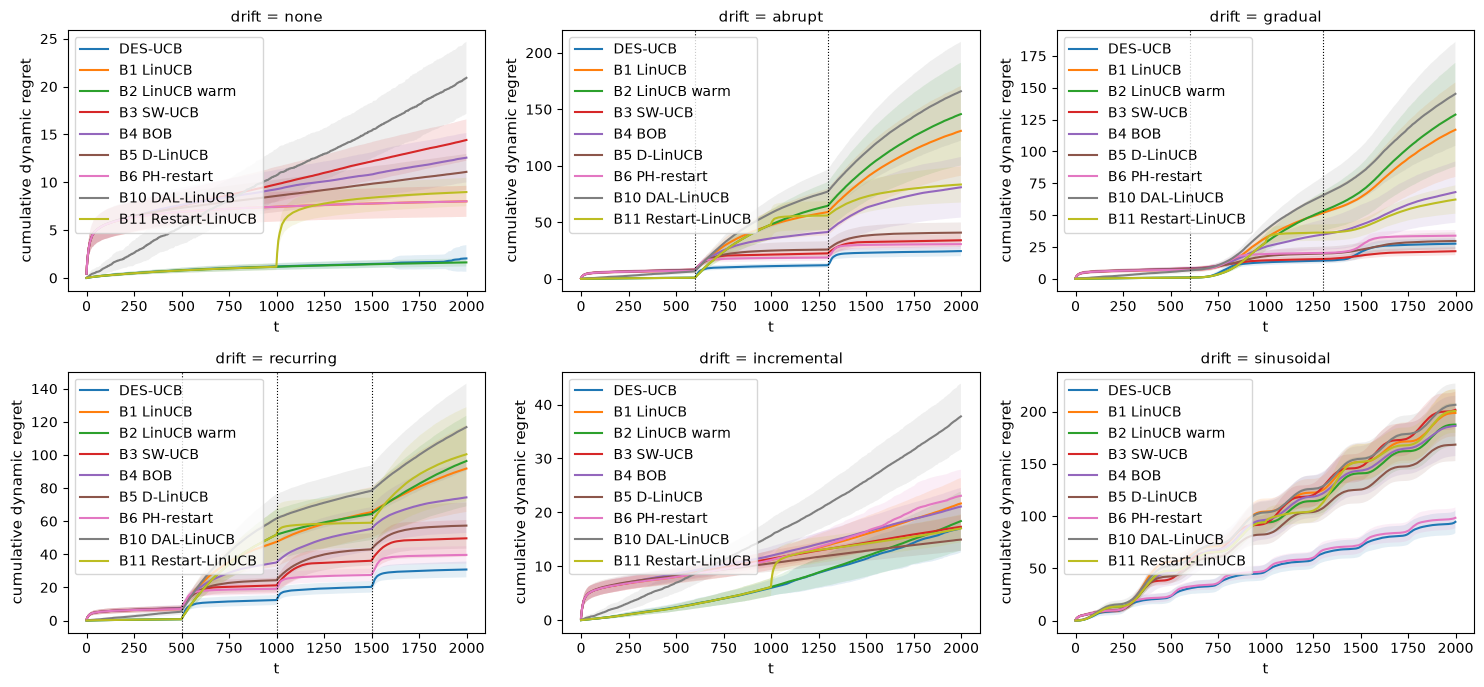

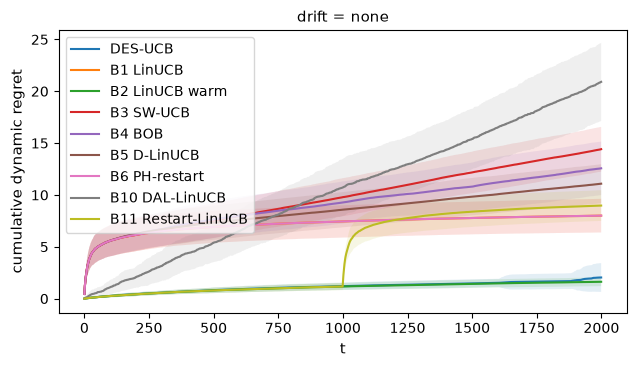

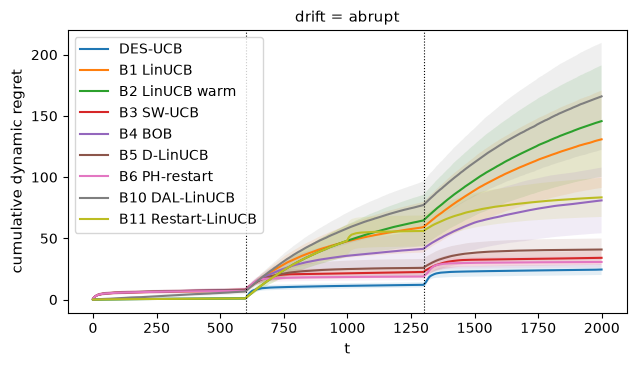

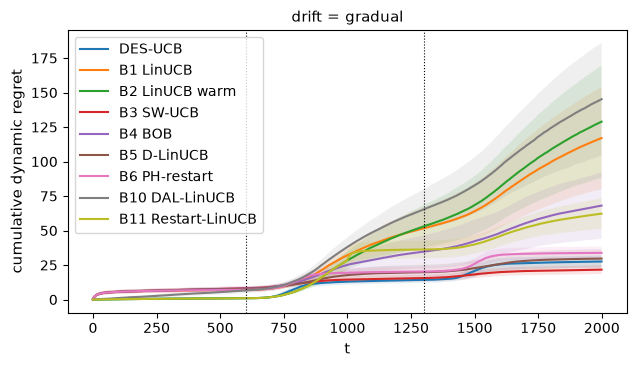

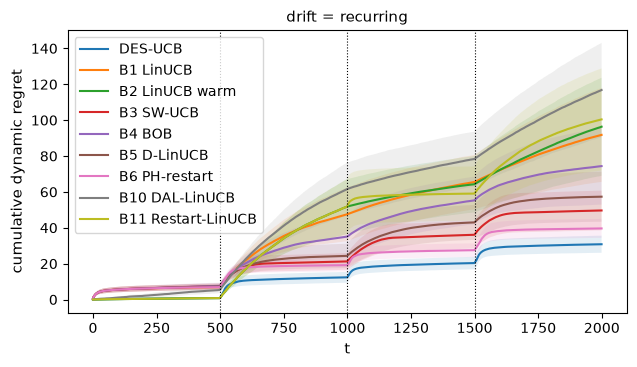

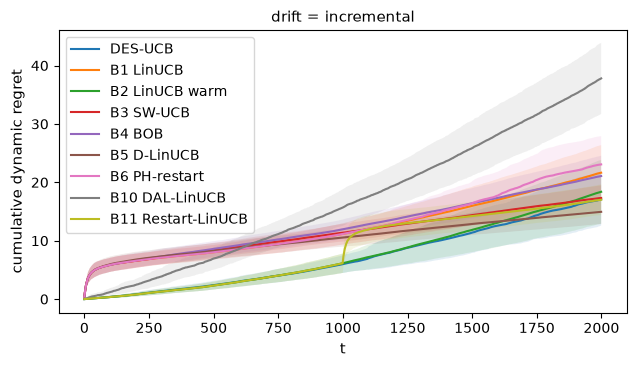

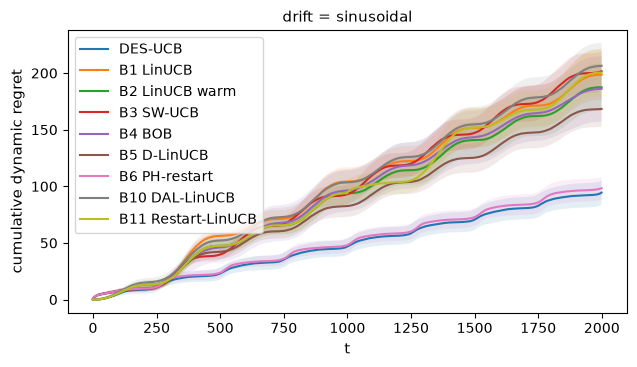

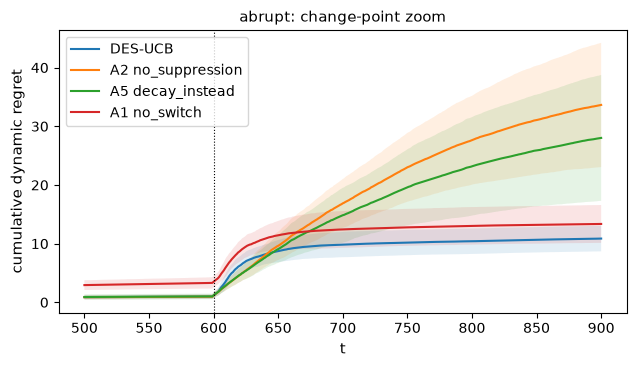

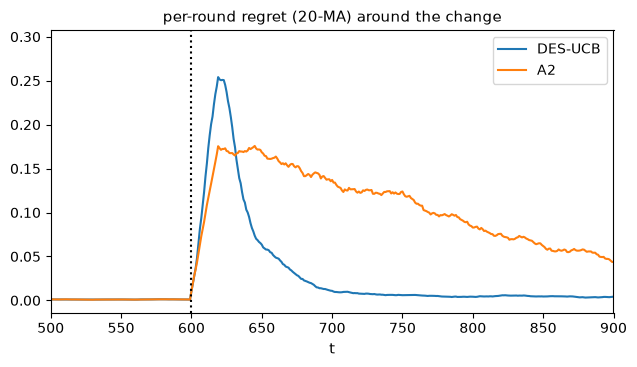

In [17]:
def plot_curves(df, agents, ax, title, zoom=None):
    cur = C.regret_curve(df)
    for a in agents:
        g = cur[cur.agent == a]
        if zoom: g = g[(g.t >= zoom[0]) & (g.t <= zoom[1])]
        ax.plot(g.t, g["mean"], label=C.AGENT_LABELS.get(a, a)); ax.fill_between(g.t, g["mean"] - g["std"], g["mean"] + g["std"], alpha=0.12)
    for cp in sorted(df.loc[df.true_change, "t"].unique()):
        if not zoom or zoom[0] <= cp <= zoom[1]: ax.axvline(cp, color="k", ls=":", lw=0.8)
    ax.set_title(title); ax.set_xlabel("t"); ax.set_ylabel("cumulative dynamic regret"); ax.legend(fontsize=10)

# one panel per saved figure, no side-by-side sub-figures
# TODO: log-scale y for the regret curves? hard to read the early rounds otherwise
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, dt in zip(axes.flat, DRIFTS):
    plot_curves(grid_logs[dt], ["DES-UCB", "B1", "B2", "B3", "B4", "B5", "B6", "B10", "B11"], ax, f"drift = {dt}")
savefig("regret_curves_grid")   # overview figure for the notebook
for dt in DRIFTS:
    fig, ax = plt.subplots(figsize=(6.5, 3.8))
    plot_curves(grid_logs[dt], ["DES-UCB", "B1", "B2", "B3", "B4", "B5", "B6", "B10", "B11"], ax, f"drift = {dt}")
    savefig(f"regret_curves_{dt}")

cp0 = int(sorted(grid_logs["abrupt"].loc[grid_logs["abrupt"].true_change, "t"].unique())[0])
fig, ax = plt.subplots(figsize=(6.5, 3.8))
plot_curves(abl_logs["abrupt"], ["DES-UCB", "A2", "A5", "A1"], ax, "abrupt: change-point zoom", zoom=(cp0 - 100, cp0 + 300))
savefig("changepoint_zoom")
pr = abl_logs["abrupt"]; pr = pr[pr.agent.isin(["DES-UCB", "A2"])]
pr_round = pr.groupby(["agent", "t"], observed=True)["regret"].mean().reset_index()
fig, ax = plt.subplots(figsize=(6.5, 3.8))
for a in ["DES-UCB", "A2"]:
    g = pr_round[pr_round.agent == a]; ax.plot(g.t, pd.Series(g.regret.to_numpy()).rolling(20).mean(), label=a)
ax.axvline(cp0, color="k", ls=":"); ax.set_xlim(cp0 - 100, cp0 + 300); ax.set_title("per-round regret (20-MA) around the change"); ax.set_xlabel("t"); ax.legend()
savefig("changepoint_perround")

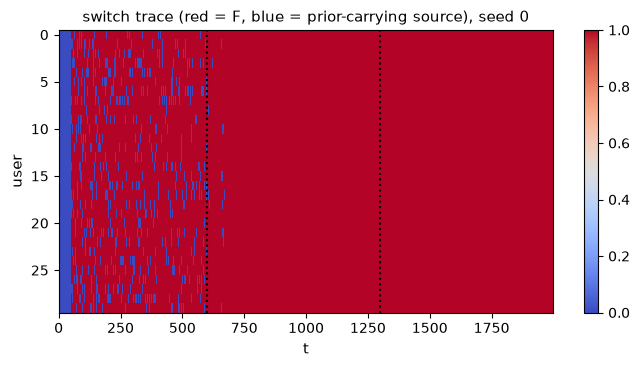

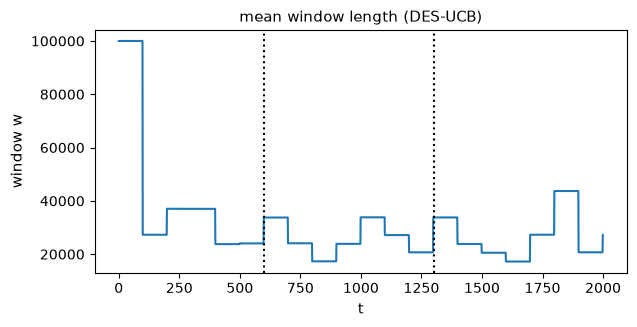

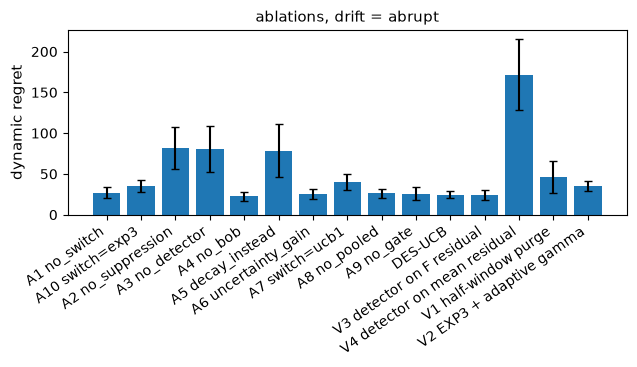

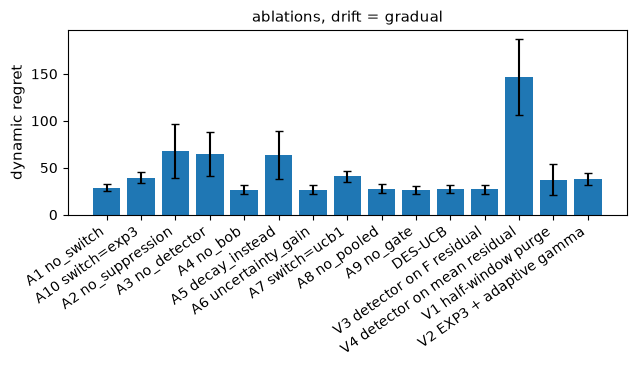

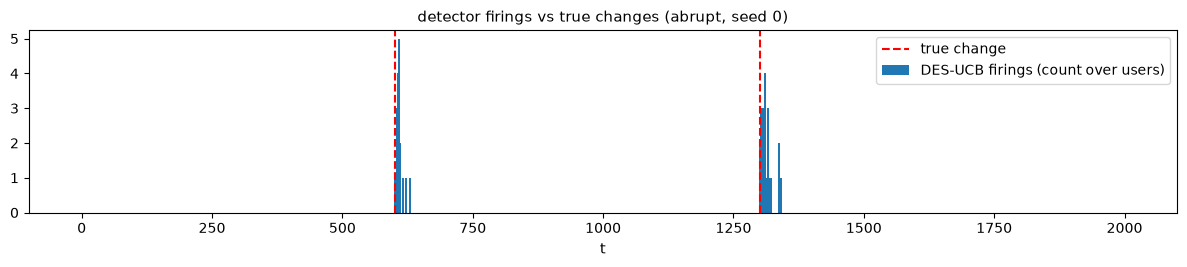

In [18]:
d = abl_logs["abrupt"]; d = d[(d.agent == "DES-UCB") & (d.seed == 0)]
piv = d.pivot_table(index="user", columns="t", values="source", aggfunc=lambda s: (s.astype(str) == "F").mean(), observed=True)
fig, ax = plt.subplots(figsize=(7, 3.8))
im = ax.imshow(piv.to_numpy(), aspect="auto", cmap="coolwarm", interpolation="nearest"); ax.set_title("switch trace (red = F, blue = prior-carrying source), seed 0")
ax.set_xlabel("t"); ax.set_ylabel("user"); plt.colorbar(im, ax=ax)
for cp in sorted(d.loc[d.true_change, "t"].unique()): ax.axvline(cp, color="k", ls=":")
savefig("switch_trace")
fig, ax = plt.subplots(figsize=(6.5, 3.4))
wtraj = d.groupby("t")["window"].mean(); ax.plot(wtraj.index, wtraj.values); ax.set_title("mean window length (DES-UCB)"); ax.set_xlabel("t"); ax.set_ylabel("window w")
for cp in sorted(d.loc[d.true_change, "t"].unique()): ax.axvline(cp, color="k", ls=":")
savefig("window_trajectory")

for dt in ["abrupt", "gradual"]:
    g = ABL[ABL.drift == dt].set_index("label")
    fig, ax = plt.subplots(figsize=(6.5, 3.8))
    ax.bar(range(len(g)), g.dyn_regret_mean, yerr=g.dyn_regret_std, capsize=3); ax.set_xticks(range(len(g))); ax.set_xticklabels(g.index, rotation=35, ha="right", fontsize=10)
    ax.set_title(f"ablations, drift = {dt}"); ax.set_ylabel("dynamic regret")
    savefig(f"ablation_bars_{dt}")

fig, ax = plt.subplots(figsize=(12, 2.8))
f = d.groupby("t")["drift_fired"].sum(); ax.bar(f.index, f.values, width=3, label="DES-UCB firings (count over users)")
for cp in sorted(d.loc[d.true_change, "t"].unique()): ax.axvline(cp, color="r", ls="--", label="true change" if cp == cp0 else None)
ax.legend(); ax.set_title("detector firings vs true changes (abrupt, seed 0)"); ax.set_xlabel("t")
savefig("detector_firings")

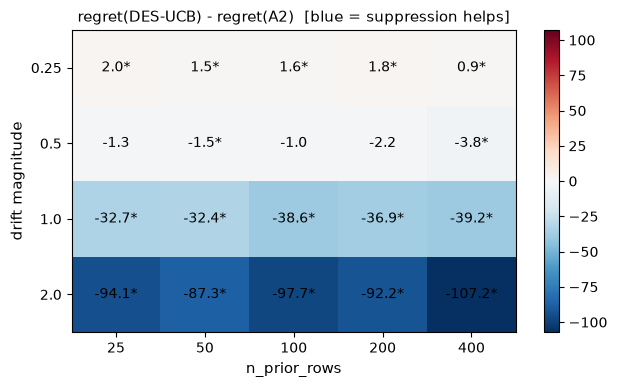

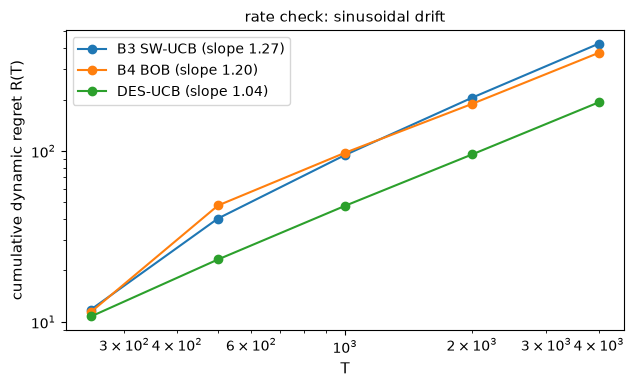

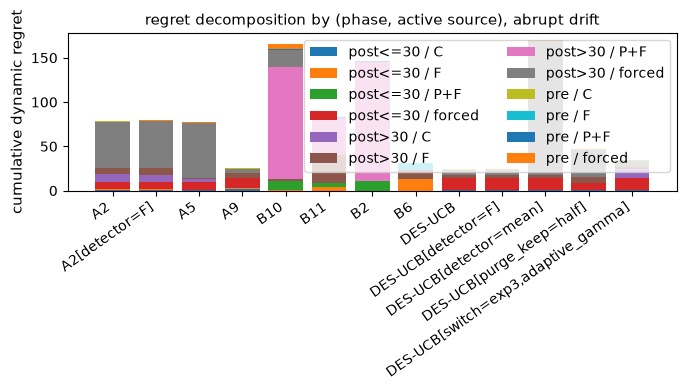

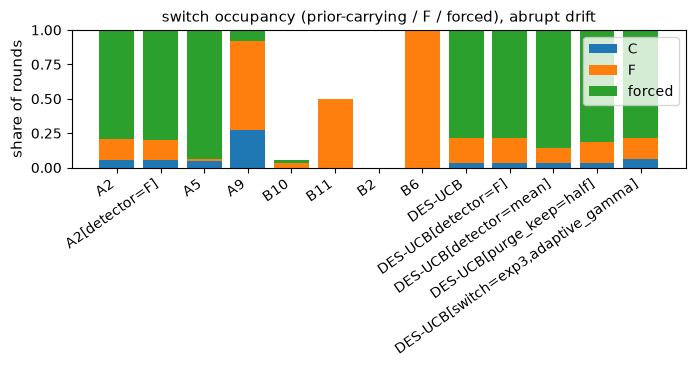

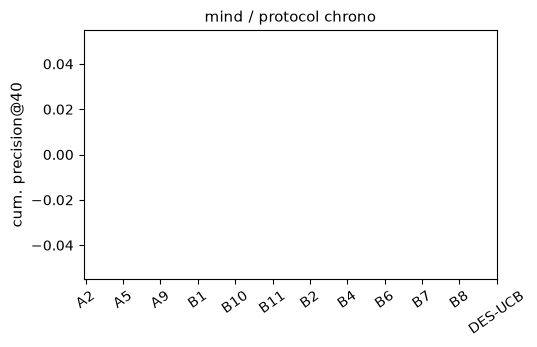

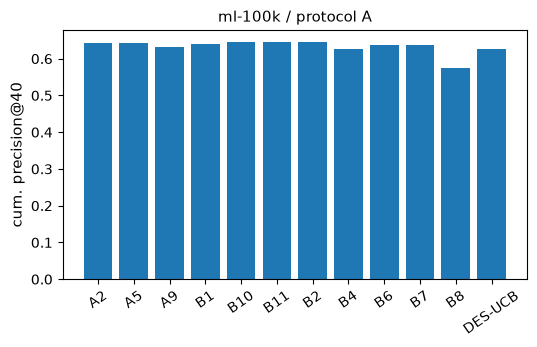

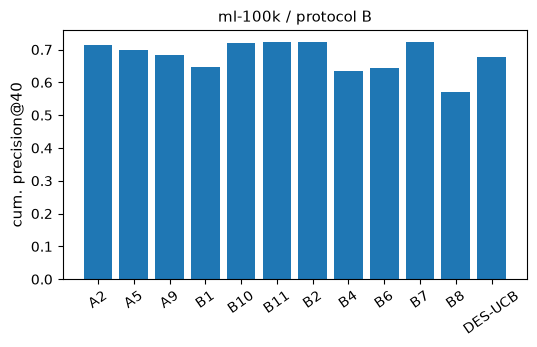

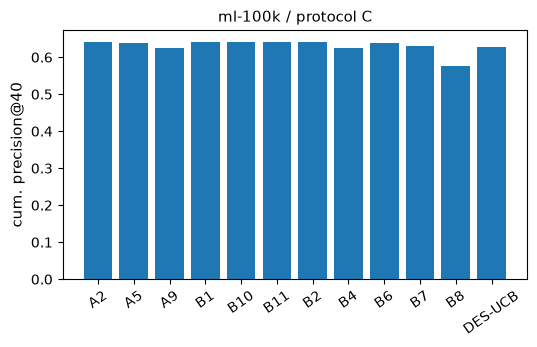

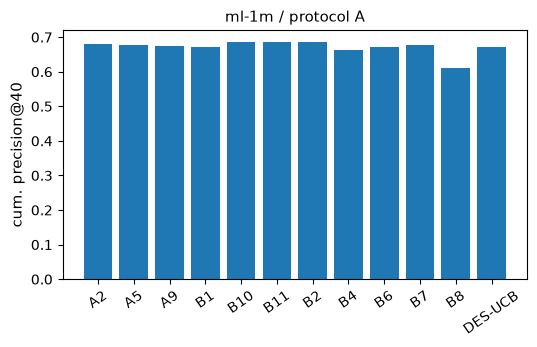

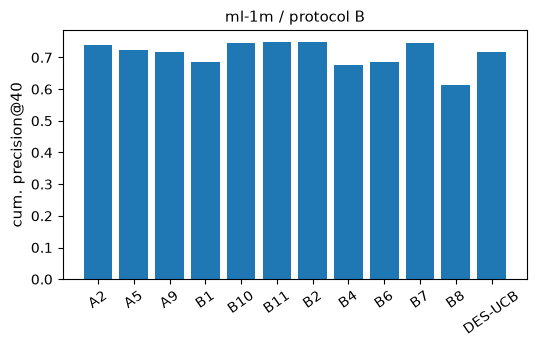

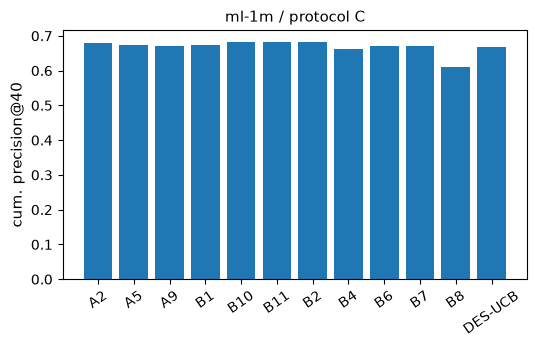

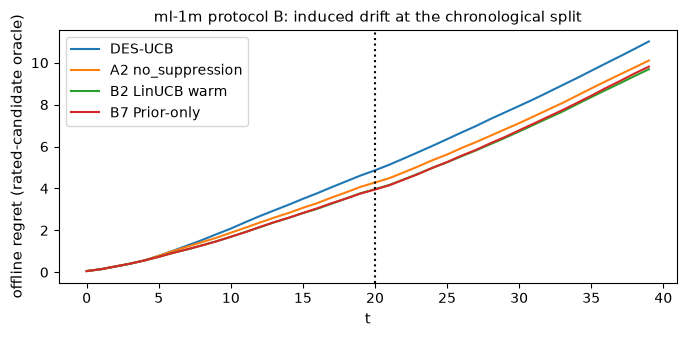

In [19]:
fig, ax = plt.subplots(figsize=(6.5, 4))
im = ax.imshow(PHASE.to_numpy(), cmap="RdBu_r", aspect="auto", vmin=-np.nanmax(np.abs(PHASE.to_numpy())), vmax=np.nanmax(np.abs(PHASE.to_numpy())))
ax.set_xticks(range(len(PHASE.columns))); ax.set_xticklabels(PHASE.columns); ax.set_yticks(range(len(PHASE.index))); ax.set_yticklabels(PHASE.index)
ax.set_xlabel("n_prior_rows"); ax.set_ylabel("drift magnitude"); ax.set_title("regret(DES-UCB) - regret(A2)  [blue = suppression helps]")
for i in range(PHASE.shape[0]):
    for j in range(PHASE.shape[1]):
        ax.text(j, i, f"{PHASE.iloc[i, j]:.1f}{'*' if phase_ci[i, j] else ''}", ha="center", va="center", fontsize=10)
plt.colorbar(im, ax=ax)
savefig("phase_diagram")
fig, ax = plt.subplots(figsize=(6.5, 4))
for a in RATE_TAB.index:
    R = [RATE_TAB.loc[a, f"R@{T}"] for T in RATE["checkpoints"]]
    ax.loglog(RATE["checkpoints"], R, "o-", label=f"{C.AGENT_LABELS.get(a, a)} (slope {RATE_TAB.loc[a, 'slope']:.2f})")
ax.set_xlabel("T"); ax.set_ylabel("cumulative dynamic regret R(T)"); ax.set_title("rate check: sinusoidal drift"); ax.legend(fontsize=10)
savefig("rate_loglog")

# diagnostics. regret split by source and phase, then switch occupancy
dec_cols = [c for c in DECOMP.columns if "total" not in (c if isinstance(c, tuple) else (c,))]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
bottom = np.zeros(len(DECOMP)); colours = plt.get_cmap("tab20")(np.linspace(0, 1, 20))
for i, c_ in enumerate(dec_cols):
    ax.bar(range(len(DECOMP)), DECOMP[c_].to_numpy(), bottom=bottom, color=colours[i % 20], label=" / ".join(map(str, c_)) if isinstance(c_, tuple) else str(c_)); bottom += DECOMP[c_].to_numpy()
ax.set_xticks(range(len(DECOMP))); ax.set_xticklabels(DECOMP.index, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("cumulative dynamic regret"); ax.set_title("regret decomposition by (phase, active source), abrupt drift")
ax.legend(fontsize=9, loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False)
savefig("regret_decomposition")
fig, ax = plt.subplots(figsize=(8.5, 3.8))
occ_cols = [c for c in ["P", "C", "F", "forced"] if c in OCC.columns]
bottom = np.zeros(len(OCC))
for c_ in occ_cols:
    ax.bar(range(len(OCC)), OCC[c_].to_numpy(), bottom=bottom, label=c_); bottom += OCC[c_].to_numpy()
ax.set_xticks(range(len(OCC))); ax.set_xticklabels(OCC.index, rotation=35, ha="right", fontsize=10)
ax.set_ylabel("share of rounds"); ax.set_title("switch occupancy (prior-carrying / F / forced), abrupt drift"); ax.legend(fontsize=9, loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False)
savefig("switch_occupancy")

if len(REALTAB):
    for dsn, pr_ in sorted(set(zip(REALTAB.dataset, REALTAB.protocol))):
        g = REALTAB[(REALTAB.dataset == dsn) & (REALTAB.protocol == pr_)].set_index("agent")
        col = [c for c in g.columns if c.startswith("cum_precision@")][-1]
        fig, ax = plt.subplots(figsize=(5.5, 3.6))
        ax.bar(range(len(g)), g[col]); ax.set_xticks(range(len(g))); ax.set_xticklabels(g.index, rotation=35, fontsize=10)
        ax.set_title(f"{dsn} / protocol {pr_}"); ax.set_ylabel(f"cum. precision@{col.split('@')[1]}")
        savefig(f"real_precision_{dsn.replace('-', '')}_{pr_}")
    if ("ml-1m", "B") in real_logs or ("ml-100k", "B") in real_logs:
        key = ("ml-1m", "B") if ("ml-1m", "B") in real_logs else ("ml-100k", "B")
        cur = C.regret_curve(real_logs[key]); fig, ax = plt.subplots(figsize=(7, 3.5))
        for a in ["DES-UCB", "A2", "B2", "B7"]:
            g = cur[cur.agent == a]; ax.plot(g.t, g["mean"], label=C.AGENT_LABELS[a])
        ax.axvline(real_logs[key].loc[real_logs[key].true_change, "t"].min(), color="k", ls=":"); ax.legend()
        ax.set_ylabel("offline regret (rated-candidate oracle)"); ax.set_xlabel("t"); ax.set_title(f"{key[0]} protocol B: induced drift at the chronological split")
        savefig("real_protocolB_offline_regret")

## 13. Claim registry

The claims were registered in advance. This section writes `results/claims.json`.

Each claim is evaluated at the registry size (`experiments.claims`, 10 seeds by 100 users at
T = 2000 unless stated). It is printed as **SUPPORTED** or **NOT SUPPORTED** with its numbers.
Failures are reported, not tuned away. The protocol has four parts. (i) The decision interval of
every paired claim is the **seed-clustered** bootstrap CI (`cl_lo`, `cl_hi`). The flat unit CI is
printed alongside. (ii) The hyper-parameters are the tuning-split selections of section 6b, never
the evaluation seeds. (iii) Detection is reported as exact counts (`detected_events` over
`n_change_events`). (iv) Every claim and threshold was fixed in `PREREGISTRATION.md` before this
run.

| claim | statement |
|---|---|
| `sanity_oracle` | the synthetic oracle is at least every agent's expected reward in every round, so regret is non-negative by construction and B9 has the lowest regret (realised reward is noisy, so the check uses expected reward) |
| `suppression` | `dyn_regret[DES] < dyn_regret[A2]`, abrupt drift, `prior_from_pre_drift`, paired 95% CI excludes 0 |
| `suppression_mis` | the same under `p_mismatch = 0.2`, `prior_from_pre_drift = false` |
| `stale_ratio` | `stale[DES] < stale[A2]`, paired CI |
| `no_harm` | `dyn_regret[DES] <= 1.10 * dyn_regret[B2]` on `drift = none` |
| `not_redundant` | `dyn_regret[DES] < dyn_regret[A5 decay]`, paired CI |
| `rate` | `slope[DES] <= slope[B4] + 0.05` |
| `real_precision` | `cum_precision@40[DES] >= cum_precision@40[B2]` on ML-1M protocol B |
| `misleading_prior` | `dyn_regret[DES] < dyn_regret[A5 decay]` when the post-drift parameter is the negated pre-drift parameter (`drift.direction = reverse`, magnitude 2) and the prior is the pre-drift cohort, clustered paired CI excludes 0 |
| `restart_not_redundant` | `dyn_regret[DES] < dyn_regret[B6 PH-restart]` on abrupt drift with a stale pre-drift prior, clustered paired CI excludes 0 (the mechanism is not a re-labelled restart) |
| `recent_baselines` | `dyn_regret[DES] < dyn_regret[B10]` **and** `< dyn_regret[B11]` on the same stream, both clustered paired CIs exclude 0 (matched tuning protocol, seeds and budget) |
| `recurring_not_redundant` | `dyn_regret[DES] < dyn_regret[B6]` on recurring drift with a stale pre-drift prior, clustered paired CI excludes 0 |

The decision-table verdict is printed at the end.

In [20]:
reg = C.ClaimRegistry(RES / "claims.json")
CL = CFG["experiments"]["claims"]
# reg = C.ClaimRegistry(RES / "claims_dev.json")  # scratch registry while the thresholds were being set
def claim_run(cfg_name, agents, tag, **over):
    cfg_c = C.load_config(cfg_name, overrides=over)
    df, _ = run_synth(cfg_c, agents, "claims", f"claims_{tag}")
    return df

# sanity_oracle. regret is oracle minus expected reward, so it is non-negative, and B9 is lowest
df_s = claim_run("drift_abrupt", ["DES-UCB", "B9", "B1", "B8"], "sanity", **{})
min_reg = float(df_s.regret.min()); r_s = C.dynamic_regret(df_s)["dynamic_regret_mean"]
reg.assert_claim("sanity_oracle", (min_reg >= -1e-9) and (r_s["B9"] <= r_s.min() + 1e-9),
                 {"min_per_round_regret": min_reg, "regret_B9": r_s["B9"], "regret_min_other": float(r_s.drop("B9").min())},
                 "oracle expected reward >= every agent's expected reward, every round")

# suppression on abrupt drift with a stale prior, plus stale_ratio and not_redundant
df_sup = claim_run("drift_abrupt", ["DES-UCB", "A2", "A5", "B4", "B6", "B10", "B11"], "suppression", prior={"prior_from_pre_drift": True, "p_mismatch": 0.0})
pu = C.per_unit(df_sup); pairs = C.summarize_pairs(pu, [("DES-UCB", b) for b in ["A2", "A5", "B6", "B10", "B11"]]).set_index("B")
r_sup = C.dynamic_regret(df_sup)["dynamic_regret_mean"]; det_sup = C.detection_stats(df_sup)
p = pairs.loc["A2"]
def ci_stats(p):
    return {"mean_diff": p["mean_diff(A-B)"], "cl_lo": p["cl_lo"], "cl_hi": p["cl_hi"], "flat_lo": p["ci_lo"], "flat_hi": p["ci_hi"],
            "seed_lo": p["seed_lo"], "seed_hi": p["seed_hi"], "n_units": int(p["n_units"]), "n_seeds": int(p["n_seeds"])}
reg.assert_claim("suppression", bool(p["mean_diff(A-B)"] < 0 and p["ci_excludes_0"]),
                 {"regret_DES": r_sup["DES-UCB"], "regret_A2": r_sup["A2"], **ci_stats(p),
                  "detector_mean_delay": det_sup.loc["DES-UCB", "mean_delay"],
                  "detected_events": int(det_sup.loc["DES-UCB", "detected"]), "n_change_events": int(det_sup.loc["DES-UCB", "n_changes"]),
                  "detected_fraction": det_sup.loc["DES-UCB", "detected"] / det_sup.loc["DES-UCB", "n_changes"]},
                 "dyn_regret[DES] < dyn_regret[A2 no_suppression] on abrupt drift with a stale (pre-drift) prior")
spu = C.stale_ratio_per_unit(df_sup); sp = C.summarize_pairs(spu, [("DES-UCB", "A2")]).iloc[0]
reg.assert_claim("stale_ratio", bool(sp["mean_diff(A-B)"] < 0 and sp["ci_excludes_0"]),
                 {"stale_DES": float(spu["DES-UCB"].mean()), "stale_A2": float(spu["A2"].mean()), **ci_stats(sp)},
                 "post-change rounds conditioned on a prior-carrying source (P or C): DES < A2")
p5 = pairs.loc["A5"]
reg.assert_claim("not_redundant", bool(p5["mean_diff(A-B)"] < 0 and p5["ci_excludes_0"]),
                 {"regret_DES": r_sup["DES-UCB"], "regret_A5_decay": r_sup["A5"], **ci_stats(p5)},
                 "purge+reset+burn-in beats passive decay of the prior (A5)")
DES_VS_B4 = float(r_sup["DES-UCB"] / r_sup["B4"])
p6 = pairs.loc["B6"]
reg.assert_claim("restart_not_redundant", bool(p6["mean_diff(A-B)"] < 0 and p6["ci_excludes_0"]),
                 {"regret_DES": r_sup["DES-UCB"], "regret_B6": r_sup["B6"], **ci_stats(p6)},
                 "evidence switching + purge beats a detector-triggered full restart (B6) on abrupt drift with a stale prior")
p10, p11 = pairs.loc["B10"], pairs.loc["B11"]
reg.assert_claim("recent_baselines", bool(p10["mean_diff(A-B)"] < 0 and p10["ci_excludes_0"] and p11["mean_diff(A-B)"] < 0 and p11["ci_excludes_0"]),
                 {"regret_DES": r_sup["DES-UCB"], "regret_B10": r_sup["B10"], "regret_B11": r_sup["B11"],
                  **{f"B10_{k}": v for k, v in ci_stats(p10).items()}, **{f"B11_{k}": v for k, v in ci_stats(p11).items()}},
                 "DES-UCB beats the matched detection-augmented (B10) and periodic-restart (B11) LinUCB baselines on abrupt drift")
pairs.reset_index().assign(claim="suppression_block").to_csv(RES / "claims_suppression_pairs.csv", index=False)

# recurring drift. does the lead over the restart route survive repeated changes?
df_rec = claim_run("drift_recurring", ["DES-UCB", "A5", "B6", "B10", "B11"], "recurring", prior={"prior_from_pre_drift": True, "p_mismatch": 0.0})
prc = C.summarize_pairs(C.per_unit(df_rec), [("DES-UCB", b) for b in ["A5", "B6", "B10", "B11"]]).set_index("B")
r_rec = C.dynamic_regret(df_rec)["dynamic_regret_mean"]; p_rec = prc.loc["B6"]
reg.assert_claim("recurring_not_redundant", bool(p_rec["mean_diff(A-B)"] < 0 and p_rec["ci_excludes_0"]),
                 {"regret_DES": r_rec["DES-UCB"], "regret_B6": r_rec["B6"], "regret_A5": r_rec["A5"], "regret_B10": r_rec["B10"], "regret_B11": r_rec["B11"], **ci_stats(p_rec)},
                 "DES-UCB beats the detector-triggered restart (B6) on recurring drift with a stale prior")
prc.reset_index().assign(claim="recurring_not_redundant").to_csv(RES / "claims_recurring_pairs.csv", index=False)

# suppression_mis
df_mis = claim_run("drift_abrupt", ["DES-UCB", "A2"], "suppression_mis", prior={"prior_from_pre_drift": False, "p_mismatch": 0.2})
pm = C.summarize_pairs(C.per_unit(df_mis), [("DES-UCB", "A2")]).iloc[0]; r_mis = C.dynamic_regret(df_mis)["dynamic_regret_mean"]
reg.assert_claim("suppression_mis", bool(pm["mean_diff(A-B)"] < 0 and pm["ci_excludes_0"]),
                 {"regret_DES": r_mis["DES-UCB"], "regret_A2": r_mis["A2"], **ci_stats(pm)},
                 "same as `suppression` under p_mismatch=0.2 with a population (not pre-drift) prior")

# misleading_prior. the post-drift theta is minus the pre-drift theta, the prior is the pre-drift cohort
df_rev = claim_run("drift_abrupt", ["DES-UCB", "A2", "A5", "B2", "B6", "B10", "B11"], "misleading_prior",
                   prior={"prior_from_pre_drift": True, "p_mismatch": 0.0}, drift={"direction": "reverse", "magnitude": 2.0})
pr_ = C.summarize_pairs(C.per_unit(df_rev), [("DES-UCB", b) for b in ["A5", "A2", "B6", "B10", "B11"]]).set_index("B")
r_rev = C.dynamic_regret(df_rev)["dynamic_regret_mean"]; p_rev = pr_.loc["A5"]
reg.assert_claim("misleading_prior", bool(p_rev["mean_diff(A-B)"] < 0 and p_rev["ci_excludes_0"]),
                 {"regret_DES": r_rev["DES-UCB"], "regret_A5_decay": r_rev["A5"], "regret_A2": r_rev["A2"], "regret_B6": r_rev["B6"], "regret_B2": r_rev["B2"],
                  "regret_B10": r_rev["B10"], "regret_B11": r_rev["B11"],
                  **ci_stats(p_rev), "mean_diff_vs_A2": pr_.loc["A2", "mean_diff(A-B)"], "cl_excl0_vs_A2": bool(pr_.loc["A2", "ci_excludes_0"])},
                 "misleading (negated) post-drift prior: purge+reset+burn-in beats passive decay (A5), clustered CI")
pr_.reset_index().assign(claim="misleading_prior").to_csv(RES / "claims_misleading_prior_pairs.csv", index=False)

# no_harm
df_none = claim_run("drift_none", ["DES-UCB", "A9", "A8", "B2", "B6", "B10", "B11"], "no_harm")
r_none = C.dynamic_regret(df_none)["dynamic_regret_mean"]
reg.assert_claim("no_harm", bool(r_none["DES-UCB"] <= 1.10 * r_none["B2"]),
                 {"regret_DES": r_none["DES-UCB"], "regret_B2": r_none["B2"], "ratio": r_none["DES-UCB"] / r_none["B2"],
                  "regret_A9_no_gate": r_none["A9"], "regret_A8_no_pooled": r_none["A8"], "regret_B6": r_none["B6"],
                  "regret_B10": r_none["B10"], "regret_B11": r_none["B11"],
                  "F_fraction_DES": float((df_none[df_none.agent == "DES-UCB"].source == "F").mean()),
                  "agreed_share_DES": float(df_none[df_none.agent == "DES-UCB"]["agreed"].mean()),
                  "false_alarms_DES": int(df_none[df_none.agent == "DES-UCB"].drift_fired.sum())},
                 "dyn_regret[DES] <= 1.10 * dyn_regret[B2 warm LinUCB] with no drift")
C.dynamic_regret(df_none).to_csv(RES / "claims_no_harm_regret.csv")

# rate, taken from section 11
reg.assert_claim("rate", bool(RATE_TAB.loc["DES-UCB", "slope"] <= RATE_TAB.loc["B4", "slope"] + 0.05),
                 {"slope_DES": RATE_TAB.loc["DES-UCB", "slope"], "slope_B4": RATE_TAB.loc["B4", "slope"], "checkpoints": RATE["checkpoints"]},
                 "log-log regret slope on sinusoidal drift: DES <= B4 + 0.05")

# real_precision on ML-1M protocol B, marked NOT RUN if the data is absent
if ("ml-1m", "B") in real_logs:
    dfb = real_logs[("ml-1m", "B")]; k = min(40, CFG_ML1M["T"])
    ppu = C.cum_precision_per_unit(dfb, k); pp = C.summarize_pairs(ppu, [("DES-UCB", "B2")]).iloc[0]
    reg.assert_claim("real_precision", bool(ppu["DES-UCB"].mean() >= ppu["B2"].mean()),
                     {"cum_precision@40_DES": float(ppu["DES-UCB"].mean()), "cum_precision@40_B2": float(ppu["B2"].mean()), **ci_stats(pp)},
                     "ML-1M protocol B: cum_precision@40[DES] >= cum_precision@40[B2]")
else:
    reg.assert_claim("real_precision", None, {"reason": "ML-1M not available in this run"}, "ML-1M protocol B: cum_precision@40[DES] >= cum_precision@40[B2]")
reg.save()

print("\nDECISION TABLE:")
for line in C.decision_table(reg, det_sup.loc["DES-UCB", "mean_delay"], CFG["burn_in_B"], DES_VS_B4, ALL_NOT_ACROSS_MAGNITUDES):
    print("  ->", line)

claims_sanity:   0%|          | 0/1000 [00:00<?, ?it/s]

[SUPPORTED] sanity_oracle: oracle expected reward >= every agent's expected reward, every round
    min_per_round_regret = 0.0
    regret_B9 = 0.0
    regret_min_other = 24.703222881348186


claims_suppression:   0%|          | 0/1000 [00:00<?, ?it/s]

[SUPPORTED] suppression: dyn_regret[DES] < dyn_regret[A2 no_suppression] on abrupt drift with a stale (pre-drift) prior
    regret_DES = 24.703222881348186
    regret_A2 = 78.00381429681731
    mean_diff = -53.300591415469086
    cl_lo = -55.62852723751748
    cl_hi = -51.17224664508306
    flat_lo = -54.97918341636722
    flat_hi = -51.55174305996145
    seed_lo = -55.20816129834551
    seed_hi = -51.39302153259268
    n_units = 1000
    n_seeds = 10
    detector_mean_delay = 8.993486973947896
    detected_events = 1996
    n_change_events = 2000
    detected_fraction = 0.998


[SUPPORTED] stale_ratio: post-change rounds conditioned on a prior-carrying source (P or C): DES < A2
    stale_DES = 0.0018000000000000002
    stale_A2 = 0.026135000000000002
    mean_diff = -0.024335000000000002
    cl_lo = -0.025465089285714282
    cl_hi = -0.02306492857142857
    flat_lo = -0.025183660714285714
    flat_hi = -0.023484125
    seed_lo = -0.025367625541826647
    seed_hi = -0.02330237445817335
    n_units = 1000
    n_seeds = 10
[SUPPORTED] not_redundant: purge+reset+burn-in beats passive decay of the prior (A5)
    regret_DES = 24.703222881348186
    regret_A5_decay = 72.99064518904616
    mean_diff = -48.28742230769798
    cl_lo = -50.46593108618095
    cl_hi = -46.2767715644976
    flat_lo = -49.99338060591759
    flat_hi = -46.50278568011952
    seed_lo = -49.76780353075904
    seed_hi = -46.80704108463692
    n_units = 1000
    n_seeds = 10
[SUPPORTED] restart_not_redundant: evidence switching + purge beats a detector-triggered full restart (B6) on abrupt drift w

...

claims_misleading_prior:   0%|          | 0/1000 [00:00<?, ?it/s]

[SUPPORTED] misleading_prior: misleading (negated) post-drift prior: purge+reset+burn-in beats passive decay (A5), clustered CI
    regret_DES = 14.525303616444388
    regret_A5_decay = 426.9964806679975
    regret_A2 = 439.0043427159449
    regret_B6 = 16.76439184197399
    regret_B2 = 847.0972746983638
    regret_B10 = 804.4460910438906
    regret_B11 = 368.536230603088
    mean_diff = -412.4711770515529
    cl_lo = -422.37708661156495
    cl_hi = -402.3566191003659
    flat_lo = -419.04702119988707
    flat_hi = -405.8128507574157
    seed_lo = -421.3556785552165
    seed_hi = -403.5866755478894
    n_units = 1000
    n_seeds = 10
    mean_diff_vs_A2 = -424.47903909950065
    cl_excl0_vs_A2 = True


claims_no_harm:   0%|          | 0/1000 [00:00<?, ?it/s]

[NOT SUPPORTED] no_harm: dyn_regret[DES] <= 1.10 * dyn_regret[B2 warm LinUCB] with no drift
    regret_DES = 2.1176628101563
    regret_B2 = 1.6605261919545458
    ratio = 1.2752962406836084
    regret_A9_no_gate = 1.9929809168197712
    regret_A8_no_pooled = 7.285553306725725
    regret_B6 = 8.326390838384187
    regret_B10 = 19.939988239089658
    regret_B11 = 8.89093359171695
    F_fraction_DES = 0.877462
    agreed_share_DES = 0.8743219971656799
    false_alarms_DES = 72


[SUPPORTED] rate: log-log regret slope on sinusoidal drift: DES <= B4 + 0.05
    slope_DES = 1.0365863632357886
    slope_B4 = 1.2046797943115721
    checkpoints = [250, 500, 1000, 2000, 4000]
[NOT SUPPORTED] real_precision: ML-1M protocol B: cum_precision@40[DES] >= cum_precision@40[B2]
    cum_precision@40_DES = 0.7179378531073446
    cum_precision@40_B2 = 0.7493785310734464
    mean_diff = -0.03144067796610169
    cl_lo = -0.034774717514124295
    cl_hi = -0.028050847457627117
    flat_lo = -0.03463347457627119
    flat_hi = -0.028247175141242944
    seed_lo = -0.03563526214055867
    seed_hi = -0.02724609379164473
    n_units = 885
    n_seeds = 3

DECISION TABLE:
  -> NO DECISION-TABLE BRANCH TRIGGERED (claims consistent with the title as stated)


## 14. Results summary

Reads `results/claims.json` and lists every supported claim with its numbers. Claims that did not
meet their registered criterion are listed separately, with their numbers. The decision table
follows. The list is saved to `results/results_summary.md`.

In [21]:
claims = json.loads((RES / "claims.json").read_text())
lines = ["# Results summary", "", "Built from results/claims.json.", "", "## Supported claims"]
sup = [c for c in claims.values() if c["verdict"] == "SUPPORTED"]
lines += [f"- **{c['claim']}** — {c['description']}. Numbers: " + ", ".join(f"{k}={v:.4g}" if isinstance(v, float) else f"{k}={v}" for k, v in c["stats"].items()) for c in sup] or ["- (none)"]
lines += ["", "## claims that missed their registered criterion"]
lines += [f"- **{c['claim']}** [{c['verdict']}] — {c['description']}. Numbers: " + ", ".join(f"{k}={v:.4g}" if isinstance(v, float) else f"{k}={v}" for k, v in c["stats"].items())
          for c in claims.values() if c["verdict"] != "SUPPORTED"] or ["- (none)"]
lines += ["", "## decision table", *[f"- {l}" for l in C.decision_table(reg, det_sup.loc['DES-UCB', 'mean_delay'], CFG['burn_in_B'], DES_VS_B4, ALL_NOT_ACROSS_MAGNITUDES)]]
(RES / "results_summary.md").write_text("\n".join(lines))
print("\n".join(lines))
print(f"\nNotebook wall time so far: {(time.time() - T_START) / 60:.1f} min")

# Results summary

Built from results/claims.json.

## Supported claims
- **sanity_oracle** — oracle expected reward >= every agent's expected reward, every round. Numbers: min_per_round_regret=0, regret_B9=0, regret_min_other=24.7
- **suppression** — dyn_regret[DES] < dyn_regret[A2 no_suppression] on abrupt drift with a stale (pre-drift) prior. Numbers: regret_DES=24.7, regret_A2=78, mean_diff=-53.3, cl_lo=-55.63, cl_hi=-51.17, flat_lo=-54.98, flat_hi=-51.55, seed_lo=-55.21, seed_hi=-51.39, n_units=1000, n_seeds=10, detector_mean_delay=8.993, detected_events=1996, n_change_events=2000, detected_fraction=0.998
- **stale_ratio** — post-change rounds conditioned on a prior-carrying source (P or C): DES < A2. Numbers: stale_DES=0.0018, stale_A2=0.02614, mean_diff=-0.02434, cl_lo=-0.02547, cl_hi=-0.02306, flat_lo=-0.02518, flat_hi=-0.02348, seed_lo=-0.02537, seed_hi=-0.0233, n_units=1000, n_seeds=10
- **not_redundant** — purge+reset+burn-in beats passive decay of the prior (A5). Numbers: r

## 15. README

### How to run
```bash
python3.11 -m venv .venv && . .venv/bin/activate
pip install -r requirements.txt
pytest -q                                   # unit tests for des_ucb_core.py
jupyter nbconvert --to notebook --execute DES_UCB.ipynb --output DES_UCB.ipynb --ExecutePreprocessor.timeout=3600
```
Configuration lives in `configs/default.yaml`, with `configs/drift_*.yaml` and
`configs/<dataset>.yaml` deep-merged through `C.load_config`. Experiment sizes sit under
`experiments:` in `default.yaml`. Runtime data is downloaded to `data/` (git-ignored). Everything
produced lands in `results/` (parquet, csv, png, `claims.json`, `results_summary.md`). Optional
datasets are enabled through `datasets:`. Yahoo R6, KuaiRand and Netflix need a local path.

### Metric glossary
* **dynamic regret** (synthetic only). `sum_t max_a x_a^T theta_t - x_{a_t}^T theta_t` against the
  hidden, time-varying oracle. It needs `theta_t`, so it exists only in simulation.
* **offline regret** (rated-item datasets). `sum_t max_{a in rated candidates} r_a - r_{a_t}`. The
  "oracle" is the best available logged reward. The candidate set is restricted to items the user
  rated. The estimate is biased by the logging process. It is not dynamic regret and is never
  called that.
* **replay reward** (uniform-random logging slices, R6 and KuaiRand). Mean logged reward over the
  rounds where the agent's action equals the logged action. This is the only real-data metric here
  that is an unbiased estimate of on-policy reward.
* **cum. precision@k and recall@T**. Hits (rating of 4 or more, or a click) in the first k rounds
  divided by k, and hits over T divided by the user's number of relevant items.
* **stale evidence ratio**. The fraction of post-change rounds on which the agent conditioned on a
  prior-carrying source. That is P, or the pooled C, which still holds the prior rows.

### Design decisions
1. `lam_threshold` was retuned from 50 to 1.0 after the pilot hit the "DETECTION FAILURE" branch
   (section 6). The PH statistic is the squared residual of the active source. Its scale is
   `sigma_reward^2`, about 0.01.
2. The generalisation gain is the relative squared-error reduction
   `(e_other - e_active)/(e_other + e_active)`. It is scale-free in `[-1, 1]` and is rescaled to
   `[0, 1]` for EXP3 with importance weighting.
3. F is not offered to the switch, nor to the agreement gate, until it holds `w_min` live rows.
   Those rounds are forced to the prior-carrying source. The Hedge controller is credited from the
   round F holds `d` rows on, since it predicts from then on. During the forced burn-in F is used
   regardless.
4. Suppression purges the live feedback down to `purge_keep` rows. The default is 0, a full
   feedback restart. V1 is the window-halving alternative. It then rebuilds the pooled source C from
   the prior rows and the kept rows, sets the prior-carrying source's Hedge weight to the F weight
   (so it starts from "no better than F"), and forces F for `max(B, w_min - |F|)` rounds.
5. Baseline hyper-parameters are chosen by the tuning protocol of section 6b. B6 restarts a warm
   LinUCB from `D_prior` on each PH firing. B10 monitors the squared residual of the forced
   (uniformly random) rounds with a GLR test and restarts cold. B11 restarts cold every
   `restart_period` rounds.
6. Real data uses a user-disjoint 85/5/10 split. SVD item factors are fit on train users only and
   frozen. ML priors use demographic cohorts (`gender|age`). MIND cohorts are the dominant clicked
   category, since no demographics are available. MIND comes from the Hugging Face mirror because
   the official blob is closed.
7. Every agent of a (seed, user) job sees the identical environment (pre-drawn noise,
   `env.reset()`), so all CIs are paired. Agent RNGs are seeded from `(seed, crc32(agent name))`.
8. Exploratory grids (sections 7 to 9 and 11) run at reduced size to fit the 30-minute budget. The
   claim registry (section 13) re-runs its cells at 5 seeds by 100 users at T = 2000.
9. `tests/test_core.py::test_des_within_10pct_of_warm_linucb_on_no_drift` is a short-horizon smoke
   check (1.25 margin at T = 400) of the `no_harm` claim. The claim itself is decided here.
10. Ablations A9 (no gate) and A8 (no pooled source) are the reference for the no-harm mechanism on
    `drift = none`. They are logged in `results/claims_no_harm_regret.csv`.

All numbers, tables and figures above were produced by running this notebook. None were
pre-filled.